<a href="https://colab.research.google.com/github/Divija062006/Optimizing-Delivery-ETAs-with-Graph-Based-Network-Intelligence/blob/main/Optimizing_Delivery_ETAs_with_Graph_Based_Network_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("/content/delivery_data.csv")
data.head(10)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
5,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 06:15:58,10.403038,15.0,11.0,12.1171,1.363636,15.0,11.0,12.1171,1.363636
6,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:47:29,18.045481,44.0,17.0,21.2890,2.588235,28.0,6.0,9.1719,4.666667
7,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:25:58,28.061896,65.0,29.0,35.8252,2.241379,21.0,11.0,14.5362,1.909091
8,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:15:56,38.939167,76.0,39.0,47.1900,1.948718,10.0,10.0,11.3648,1.000000
9,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 04:49:20,43.595802,102.0,45.0,53.2334,2.266667,26.0,6.0,6.0434,4.333333


In [ ]:
data.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


In [ ]:
data.shape

(144867, 24)

In [ ]:
data.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [ ]:
data[["od_start_time","od_end_time","start_scan_to_end_scan","is_cutoff","cutoff_factor","cutoff_timestamp"]][:10]

,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp
0,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55
1,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55
2,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586
3,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57
4,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55
5,2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,9,2018-09-20 06:15:58
6,2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,18,2018-09-20 05:47:29
7,2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,27,2018-09-20 05:25:58
8,2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,True,36,2018-09-20 05:15:56
9,2018-09-20 04:47:45.236797,2018-09-20 06:36:55.627764,109.0,False,43,2018-09-20 04:49:20


In [ ]:
data[data["source_name"].isna()]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
112,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 14:09:19,22.783440,48.0,34.0,37.7749,1.411765,48.0,34.0,37.7749,1.411765
113,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 13:19:23,46.071250,98.0,41.0,56.3575,2.390244,49.0,33.0,34.1661,1.484848
114,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 12:49:33,67.714993,127.0,58.0,80.4811,2.189655,29.0,17.0,24.1236,1.705882
115,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 12:21:18,88.149642,156.0,73.0,101.2556,2.136986,28.0,14.0,20.7746,2.000000
116,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 11:25:24,112.691981,212.0,92.0,127.9860,2.304348,55.0,18.0,26.7304,3.055556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144484,test,2018-10-03 09:06:06.690094,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND282002AAD,NaN,IND474003AAA,Gwalior_HrihrNgr_I (Madhya Pradesh),2018-10-03 17:34:21.835475,...,2018-10-03 20:54:08,45.134384,62.0,45.0,47.7734,1.377778,34.0,23.0,23.6601,1.478261
144485,test,2018-10-03 09:06:06.690094,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND282002AAD,NaN,IND474003AAA,Gwalior_HrihrNgr_I (Madhya Pradesh),2018-10-03 17:34:21.835475,...,2018-10-03 20:30:09,66.542266,86.0,71.0,71.9549,1.211268,23.0,25.0,24.1815,0.920000
144486,test,2018-10-03 09:06:06.690094,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND282002AAD,NaN,IND474003AAA,Gwalior_HrihrNgr_I (Madhya Pradesh),2018-10-03 17:34:21.835475,...,2018-10-03 20:00:08,88.143957,116.0,114.0,112.6943,1.017544,30.0,43.0,40.7394,0.697674
144487,test,2018-10-03 09:06:06.690094,thanos::sroute:cbef3b6a-79ea-4d5e-a215-b558a70...,FTL,trip-153855756668984584,IND282002AAD,NaN,IND474003AAA,Gwalior_HrihrNgr_I (Madhya Pradesh),2018-10-03 17:34:21.835475,...,2018-10-03 19:02:11,111.084417,173.0,123.0,134.1940,1.406504,57.0,45.0,46.9217,1.266667


In [ ]:
data[111:113]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
111,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342601AAA,Piparcity_BsstdDPP_D (Rajasthan),IND342902A1B,NaN,2018-09-26 05:04:49.254901,...,2018-09-26 05:04:49.254901,34.657709,110.0,43.0,41.5361,2.558140,52.0,10.0,10.6517,5.200000
112,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,...,2018-09-26 14:09:19,22.783440,48.0,34.0,37.7749,1.411765,48.0,34.0,37.7749,1.411765


In [ ]:
data = data.drop(columns = ["source_name", "destination_name"])

In [ ]:
data = data.dropna()
data.shape

(144867, 22)

In [ ]:
data.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
destination_center,0
od_start_time,0
od_end_time,0
start_scan_to_end_scan,0


In [ ]:
import networkx as nx

In [ ]:
# 1. Initializing the Directed Graph
G = nx.DiGraph()

# 2. Adding all unique centers as nodes
all_centers = set(data['source_center'].unique()).union(set(data['destination_center'].unique()))
G.add_nodes_from(all_centers)

# 3. Get only the unique directed routes (edges)
# drop_duplicates gives us just the unique pairs without any aggregation or math
unique_routes = data[['source_center', 'destination_center']].drop_duplicates()

# 4. Add the edges to the graph (no weights or features included yet)
for _, row in unique_routes.iterrows():
    G.add_edge(row['source_center'], row['destination_center'])

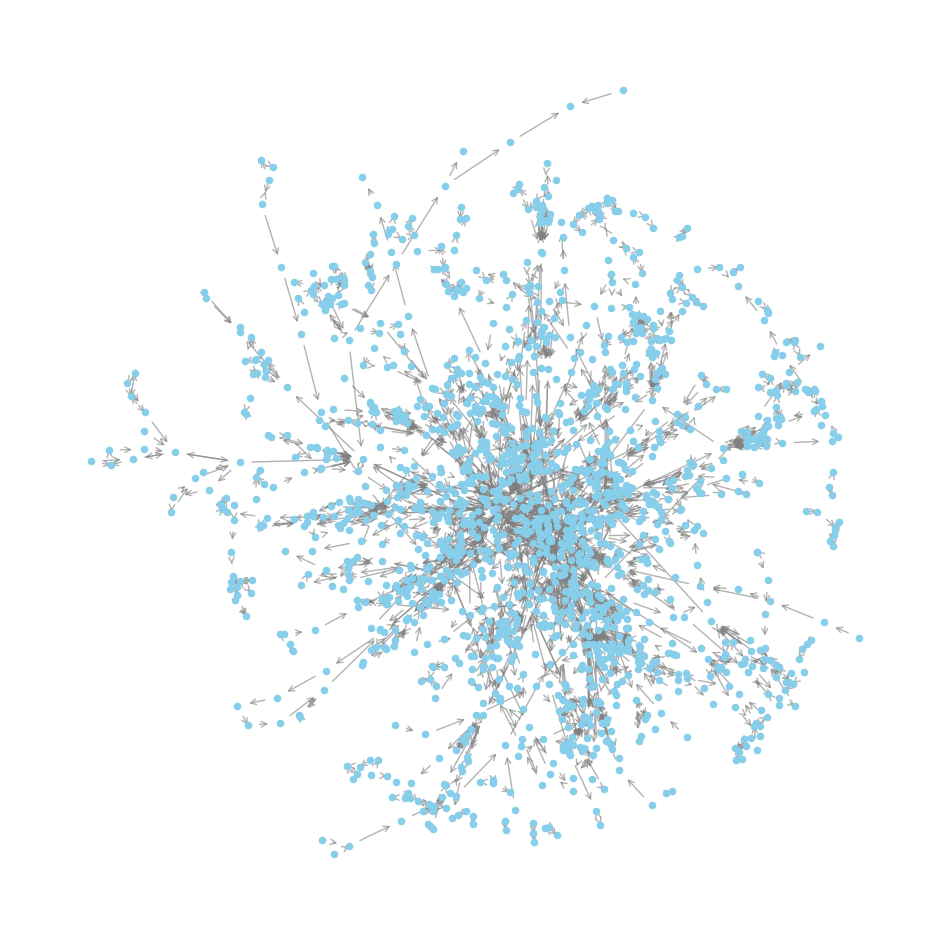

In [ ]:
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.15, seed=42)
nx.draw_networkx_nodes(G, pos,node_size=20, node_color='skyblue')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=10, edge_color='gray', alpha=0.6)
plt.axis('off')
plt.show()

In [ ]:
# --- STEP 1: TIME OF DAY STRATIFICATION ---
data['cutoff_timestamp'] = pd.to_datetime(data['cutoff_timestamp'], format = 'mixed')

def get_time_of_day(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 22: return 'Evening'
    else: return 'Night'

data['time_of_day'] = data['cutoff_timestamp'].dt.hour.apply(get_time_of_day)


# --- STEP 2: AGGREGATE AT THE LEG LEVEL (Isolating the Multi-Stops) ---
# Grouping by trip AND both centers perfectly isolates Leg 1 from Leg 2
leg_features = data.groupby(['trip_uuid', 'source_center', 'destination_center']).agg(
    route_type=('route_type', 'first'),
    time_of_day=('time_of_day', 'first'),

    # Feature 1: The max value at the start of the leg represents the true leg distance
    leg_actual_dist=('actual_distance_to_destination', 'max'),

    # Summing the incremental segments isolates times to just this leg
    leg_actual_time=('segment_actual_time', 'sum'),
    leg_osrm_time=('segment_osrm_time', 'sum'),
    leg_osrm_dist=('segment_osrm_distance', 'sum')
).reset_index()

# Feature 2: Delay Ratio for this specific leg
leg_features['leg_delay_ratio'] = leg_features['leg_actual_time'] / leg_features['leg_osrm_time']

# Feature 3: Ratio of total actual distance vs OSRM planned distance for this leg
leg_features['leg_distance_ratio'] = leg_features['leg_actual_dist'] / leg_features['leg_osrm_dist']


# --- STEP 3: GLOBAL STRATIFICATION (Median across all trips for a corridor) ---
corridors = leg_features.groupby(['source_center', 'destination_center', 'route_type', 'time_of_day']).agg(
    edge_weight_delay_ratio=('leg_delay_ratio', 'median'),
    edge_total_distance=('leg_actual_dist', 'median'),
    edge_distance_ratio=('leg_distance_ratio', 'median')
).reset_index()

In [ ]:
# Create a multi-index lookup with just the text features in the index
corridors_lookup = corridors.set_index(['source_center', 'destination_center'])

for source, destination in G.edges():
    edge_key = (source, destination)

    if edge_key in corridors_lookup.index:
        matching_rows = corridors_lookup.loc[[edge_key]]

        # Build a structured profile for every combination on this lane
        lane_profile = {}
        for _, row in matching_rows.iterrows():
            strat_key = f"{row['route_type']}_{row['time_of_day']}"
            lane_profile[strat_key] = {
                'weight': row['edge_weight_delay_ratio'],
                'distance': row['edge_total_distance'],
                'dist_ratio': row['edge_distance_ratio']
            }

        # Attach the entire structured dictionary to the edge
        G[source][destination]['profiles'] = lane_profile

In [ ]:
# verification
import random

# Ensure your graph has edges before trying to sample
if len(G.edges()) > 0:
    # 1. Grab a random edge from the graph
    random_edge = random.choice(list(G.edges()))
    source, destination = random_edge

    #2. Extract and print its metadata dictionary
    edge_data = G.get_edge_data(source, destination)

    print("--- RANDOM EDGE VERIFICATION ---")
    print(f"Source Center      : {source}")
    print(f"Destination Center : {destination}")
    print(f"Attached Attributes: {edge_data}")
else:
    print("The graph doesn't have any edges yet!")

--- RANDOM EDGE VERIFICATION ---
Source Center      : IND302014AAA
Destination Center : IND301001AAB
Attached Attributes: {'profiles': {'FTL_Evening': {'weight': 1.5912408759124088, 'distance': 114.40539568405252, 'dist_ratio': 0.6946179201338185}}}


In [ ]:
# ==========================================
# PHASE 1: HUB BOTTLENECK AUDIT (NODE METRICS)
# ==========================================

# 1. Compute Directed Betweenness Centrality (strictly respecting arrow directions)
betweenness = nx.betweenness_centrality(G, normalized=True)

# 2. Compute Degrees (In, Out, and Total)
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

# 3. Compile Hub Audit Metrics into a ranked DataFrame
hub_audit = pd.DataFrame({
    'Hub_Name': list(G.nodes()),
    'Betweenness_Centrality': [betweenness[node] for node in G.nodes()],
    'In_Degree': [in_degrees[node] for node in G.nodes()],
    'Out_Degree': [out_degrees[node] for node in G.nodes()],
    'Total_Degree': [total_degrees[node] for node in G.nodes()]
}).sort_values(by='Betweenness_Centrality', ascending=False).reset_index(drop=True)

print("--- TOP 10 CRITICAL CHOKEPOINT HUBS ---")
print(hub_audit.head(10).to_string())
print("\n" + "="*50 + "\n")


# ==========================================
# PHASE 2: GLOBAL CORRIDOR AUDIT & SLA BREACH RANKING
# ==========================================

# 1. Identify rows where actual time exceeds OSRM by >20%
leg_features['is_sla_breach'] = leg_features['leg_delay_ratio'] > 1.20

# 2. Calculate the total number of breaches across the entire network for contribution ranking
total_network_breaches = leg_features['is_sla_breach'].sum()

# 3. Group by corridor, route type, and time of day
corridor_strategy = leg_features.groupby(
    ['source_center', 'destination_center', 'route_type', 'time_of_day']
).agg(
    total_trips=('trip_uuid', 'count'),
    breach_count=('is_sla_breach', 'sum'),
    sla_breach_rate=('is_sla_breach', 'mean'),        # Percentage of trips on this lane breaking SLA
    median_delay_factor=('leg_delay_ratio', 'median'), # How bad the delay is when it happens
    median_actual_distance=('leg_actual_dist', 'median')
).reset_index()

# 4. Calculate SLA Breach Contribution (%)
# This tells you which lanes are responsible for the biggest chunk of your network's overall delays
corridor_strategy['sla_breach_contribution_pct'] = (corridor_strategy['breach_count'] / total_network_breaches) * 100

# 5. Sort by Breach Contribution to target the highest impact lanes first
corridor_strategy = corridor_strategy.sort_values(by='sla_breach_contribution_pct', ascending=False).reset_index(drop=True)

print("--- TOP 15 LANES CONTRIBUTING TO NETWORK SLA BREACHES ---")
# Removed the trip filter so EVERYTHING shows up, sorted by worst offender first
print(corridor_strategy.head(15).to_string())

--- TOP 10 CRITICAL CHOKEPOINT HUBS ---
       Hub_Name  Betweenness_Centrality  In_Degree  Out_Degree  Total_Degree
0  IND000000ACB                0.220228         45          49            94
1  IND562132AAA                0.124943         36          35            71
2  IND501359AAE                0.092632         30          27            57
3  IND712311AAA                0.090659         24          22            46
4  IND421302AAG                0.069625         29          29            58
5  IND160002AAC                0.055078         32          29            61
6  IND131028AAB                0.047837         20          20            40
7  IND781018AAB                0.044542         17          15            32
8  IND411033AAA                0.043254         23          20            43
9  IND600056AAB                0.042146         18          18            36


--- TOP 15 LANES CONTRIBUTING TO NETWORK SLA BREACHES ---
   source_center destination_center route_type time_o

In [ ]:
# =======================================================
# SORTED EXTREME OPERATIONAL BOTTLENECK ANALYSIS (>= 20x Delay)
# =======================================================

# Filter for lanes where the median delay factor is 20x or higher
extreme_20x_lanes = corridor_strategy[corridor_strategy['median_delay_factor'] >= 20.0]

# Sort the results in descending order by the delay factor
extreme_20x_lanes_sorted = extreme_20x_lanes.sort_values(by='median_delay_factor', ascending=False).reset_index(drop=True)

print(f"Total lanes with a median delay of 20x or more: {len(extreme_20x_lanes_sorted)}")
print("-" * 60)

if len(extreme_20x_lanes_sorted) > 0:
    # Display the full sorted list of anomalies
    print(extreme_20x_lanes_sorted[['source_center', 'destination_center', 'route_type', 'time_of_day', 'total_trips', 'median_delay_factor']].to_string())
else:
    print("No lanes have a median delay factor above 20x.")

Total lanes with a median delay of 20x or more: 24
------------------------------------------------------------
   source_center destination_center route_type time_of_day  total_trips  median_delay_factor
0   IND395006AAA       IND395023AAD    Carting     Morning            1            70.000000
1   IND211008AAA       IND211002AAB    Carting       Night            2            58.241486
2   IND271001AAA       IND271210AAA    Carting     Morning            1            53.893617
3   IND208012AAA       IND209304AAA    Carting       Night            1            49.473684
4   IND431136AAC       IND431001AAA    Carting     Evening            1            46.100000
5   IND208012AAA       IND209304AAA    Carting   Afternoon            1            36.500000
6   IND452001AAC       IND425201AAA    Carting     Morning            2            34.916667
7   IND785634AAA       IND785001AAA    Carting       Night            1            32.937500
8   IND208012AAA       IND209304AAA    Carting     

In [ ]:
# Filter down to lanes that have real statistical volume (>10 trips) and are breaching (>1.2)
strategic_pool = corridor_strategy[
    (corridor_strategy['median_delay_factor'] > 1.2) &
    (corridor_strategy['total_trips'] > 10)
].copy()

# Sort by their overall damage to the network
strategic_pool = strategic_pool.sort_values(by='sla_breach_contribution_pct', ascending=False).reset_index(drop=True)

# LIST 1: The Top 10 Networks with Highest SLA Breach Contribution
# These 10 lanes represent the highest combination of high trips + high delays. Fix these first.
top_10_network_killers = strategic_pool.head(10)

# LIST 2: The Operational Standstills (Median Delay >= 5.0x OSRM time, with >10 trips)
# These are the high-volume lanes where trucks are fundamentally getting stuck for days.
operational_standstills = strategic_pool[strategic_pool['median_delay_factor'] >= 5.0].head(10)

# LIST 3: The Quick Wins (High Trips, but low median delay factor between 1.2 and 1.5)
# These are busy lanes that are just slightly lagging. Minor tweaks to scheduling will save them.
quick_wins = strategic_pool[(strategic_pool['median_delay_factor'] > 1.2) & (strategic_pool['median_delay_factor'] <= 1.5)].head(10)


print("=== ACTION ITEM 1: TOP 10 NETWORK KILLERS (FIX FIRST) ===")
print(top_10_network_killers[['source_center', 'destination_center', 'route_type', 'time_of_day', 'total_trips', 'median_delay_factor', 'sla_breach_contribution_pct']].to_string())

print("\n" + "="*80 + "\n")

print("=== ACTION ITEM 2: CRITICAL OPERATIONAL STANDSTILLS (DELAYS >= 5x) ===")
if len(operational_standstills) > 0:
    print(operational_standstills[['source_center', 'destination_center', 'route_type', 'time_of_day', 'total_trips', 'median_delay_factor']].to_string())
else:
    print("No lanes with >10 trips have a median delay factor worse than 5x. (Excellent!)")

print("\n" + "="*80 + "\n")

print("=== ACTION ITEM 3: TOP 10 QUICK WINS (EASY SCHEDULING TWEAKS) ===")
print(quick_wins[['source_center', 'destination_center', 'route_type', 'time_of_day', 'total_trips', 'median_delay_factor']].to_string())

=== ACTION ITEM 1: TOP 10 NETWORK KILLERS (FIX FIRST) ===
  source_center destination_center route_type time_of_day  total_trips  median_delay_factor  sla_breach_contribution_pct
0  IND411033AAA       IND421302AAG        FTL     Morning           54             1.863492                     0.225122
1  IND421302AAG       IND411033AAA        FTL       Night           40             1.775845                     0.166757
2  IND000000ACB       IND562132AAA        FTL     Morning           39             1.619186                     0.162588
3  IND110044AAB       IND000000ACB    Carting     Evening           39             1.606557                     0.158419
4  IND400011AAA       IND400072AAD    Carting     Evening           38             2.567251                     0.154250
5  IND562132AAA       IND560300AAA    Carting   Afternoon           37             1.765957                     0.154250
6  IND400072AAD       IND421302AAG    Carting       Night           37             2.437500    

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio  # <-- Added this to fix the NameError!
import numpy as np

# 1. Compute Betweenness Centrality
betweenness = nx.betweenness_centrality(G, normalized=True)
b_values = np.array([betweenness[node] for node in G.nodes()])

# 2. Fix the color distribution using Percentile Binning
max_val = np.percentile(b_values, 99) if len(b_values) > 0 else 1.0
normalized_colors = np.clip(b_values / (max_val if max_val > 0 else 1), 0, 1)

# 3. Calculate position layout
pos = nx.kamada_kawai_layout(G)

# 4. Construct dark, visible Directed Edges (Arrows)
edge_traces = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]

    edge_traces.append(
        go.Scatter(
            x=[x0, x1, None], y=[y0, y1, None],
            line=dict(width=1.2, color='#2c3e50'),
            hoverinfo='none',
            mode='lines'
        )
    )

# 5. Construct the Interactive Nodes (With Hover Pop-ups)
node_x = []
node_y = []
node_text = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"Hub ID: {node}<br>Betweenness: {betweenness[node]:.5f}")

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    text=node_text,
    marker=dict(
        showscale=True,
        colorscale='Plasma',
        color=normalized_colors,
        size=9,
        colorbar=dict(
            title=dict(text='Chokepoint Intensity', font=dict(size=12, family='Arial', weight='bold')),
            thickness=15,
            xanchor='left'
        ),
        line=dict(width=0.5, color='#ffffff')
    )
)

# 6. Assemble into an interactive layout html file
fig = go.Figure(
    data=[*edge_traces, node_trace],
    layout=go.Layout(
        title='<br>Interactive Supply Chain Network Bottleneck Audit',
        titlefont_size=16,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=20, l=5, r=5, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        template='plotly_white'
    )
)

# 7. Save the standalone file
fig.write_html('interactive_network_map.html')

# 8. Force immediate inline rendering inside your notebook cell
pio.renderers.default = 'colab'  # Use 'iframe' here if you are on standard local Jupyter
fig.show()

In [ ]:
import pandas as pd

# =======================================================
# PHASE 2 EXTENSION: HUB-LEVEL SLA BREACH RANKING
# =======================================================

# 1. Split the corridor breach data into Source Hub contributions
source_hubs = corridor_strategy[['source_center', 'breach_count']].rename(
    columns={'source_center': 'hub_id'}
)

# 2. Split into Destination Hub contributions
dest_hubs = corridor_strategy[['destination_center', 'breach_count']].rename(
    columns={'destination_center': 'hub_id'}
)

# 3. Combine both views to catch a hub's full footprint (Inbound + Outbound)
combined_hubs = pd.concat([source_hubs, dest_hubs], axis=0)

# 4. Aggregate total breaches by Hub ID
hub_ranking = combined_hubs.groupby('hub_id').agg(
    total_hub_breaches=('breach_count', 'sum')
).reset_index()

# 5. Calculate global network breach contribution percentage for each hub
hub_ranking['hub_breach_contribution_pct'] = (hub_ranking['total_hub_breaches'] / total_network_breaches) * 100

# 6. Sort by worst offenders first
hub_ranking = hub_ranking.sort_values(by='hub_breach_contribution_pct', ascending=False).reset_index(drop=True)

# 7. Offset index by 1 so Row Index matches Rank exactly (n-th row == n-th rank)
hub_ranking.index = hub_ranking.index + 1

In [ ]:
hub_ranking.head(4)

,hub_id,total_hub_breaches,hub_breach_contribution_pct
1,IND000000ACB,1689,7.041314
2,IND421302AAG,1403,5.849002
3,IND562132AAA,1296,5.402927
4,IND160002AAC,735,3.064160


In [ ]:
!pip install node2vec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 745.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 48.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have num

In [ ]:
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# =======================================================
# STEP 1: GENERATE GRAPH EMBEDDINGS USING NODE2VEC
# =======================================================
print("Generating network node embeddings via Node2Vec...")
# Precompute random walks on your graph G (adjust dimensions for speed if needed)
node2vec_engine = Node2Vec(G, dimensions=16, walk_length=10, num_walks=20, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)

# Extract embedding vectors into a dictionary
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

# =======================================================
# STEP 2: PREPARE THE DATASETS (BASELINE VS GRAPH)
# =======================================================
df_ml = leg_features.copy()

# Base columns we definitely want
baseline_cols = ['leg_actual_dist']

# Dynamic Fallback Check: Only try to parse the hour if the timestamp column exists
if 'trip_creation_time' in df_ml.columns:
    df_ml['hour'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
    baseline_cols.append('hour')
elif 'time_of_day' in df_ml.columns:
    # If time_of_day is categorical (e.g., 'Morning', 'Night'), convert it to numbers
    df_ml['hour'] = pd.factorize(df_ml['time_of_day'])[0]
    baseline_cols.append('hour')
else:
    print("Timestamp columns not found; benchmark will safely proceed using distance metrics alone.")

# Define baseline feature matrix X and target y (Actual Leg Travel Time)
X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

# Construct the Graph-Enhanced Feature Matrix
# Map source and destination Hub IDs to their precomputed vectors
src_vectors = np.array([node_embeddings.get(src, np.zeros(embedding_dim)) for src in df_ml['source_center']])
dst_vectors = np.array([node_embeddings.get(dst, np.zeros(embedding_dim)) for dst in df_ml['destination_center']])

# Combine baseline features with graph structural vectors
X_graph = np.hstack((X_base.values, src_vectors, dst_vectors))

# Split both consistently into train/test splits
X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

# =======================================================
# STEP 3: TRAIN MODELS AND GENERATE PREDICTIONS
# =======================================================
print("Training Baseline Model...")
model_baseline = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

print("Training Graph-Enhanced Model...")
model_graph = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)

# =======================================================
# STEP 4: EVALUATE PERFORMANCE & GRAPH ADVANTAGE
# =======================================================
# Metric 1: Mean Absolute Error
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

# Metric 2: Percentage of trips within 15% of actual values
def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

# Print out the formal verification requested by the prompt
print("\n" + "="*50)
print("             THE GRAPH ADVANTAGE AUDIT           ")
print("="*50)
print(f"Baseline MAE:         {mae_base:.2f} minutes")
print(f"Graph-Enhanced MAE:   {mae_graph:.2f} minutes")
print(f"--> MAE Improvement:  {mae_base - mae_graph:.2f} minutes less error\n")
print(f"Baseline Trips within 15% Accuracy:       {pct_within_15_base:.2f}%")
print(f"Graph-Enhanced Trips within 15% Accuracy: {pct_within_15_graph:.2f}%")
print(f"--> Accuracy Bracket Uplift:             {pct_within_15_graph - pct_within_15_base:+.2f}%")
print("="*50)

Generating network node embeddings via Node2Vec...
Training Baseline Model...
Training Graph-Enhanced Model...

             THE GRAPH ADVANTAGE AUDIT           
Baseline MAE:         50.41 minutes
Graph-Enhanced MAE:   41.13 minutes
--> MAE Improvement:  9.28 minutes less error

Baseline Trips within 15% Accuracy:       28.33%
Graph-Enhanced Trips within 15% Accuracy: 33.03%
--> Accuracy Bracket Uplift:             +4.70%


In [ ]:
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor  # Upgraded to a boosting engine
from sklearn.metrics import mean_absolute_error

print("Precomputing explicit graph topology metrics...")
# 1. Compute explicit structural features to hand directly to the model
betweenness = nx.betweenness_centrality(G, normalized=True)
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

print("Generating network node embeddings via Node2Vec...")
# 2. Keep Node2Vec to capture structural neighborhoods
node2vec_engine = Node2Vec(G, dimensions=16, walk_length=12, num_walks=30, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

# =======================================================
# DATA PREPARATION WITH DEEP GRAPH METRICS
# =======================================================
df_ml = leg_features.copy()
baseline_cols = ['leg_actual_dist']

if 'trip_creation_time' in df_ml.columns:
    df_ml['hour'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
    baseline_cols.append('hour')
elif 'time_of_day' in df_ml.columns:
    df_ml['hour'] = pd.factorize(df_ml['time_of_day'])[0]
    baseline_cols.append('hour')

X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

# 3. Construct the advanced graph matrix (Embeddings + Explicit Centralities)
graph_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']

    # Get vectors or fallback to zeros
    src_v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_v = node_embeddings.get(dst, np.zeros(embedding_dim))

    # Extract explicit chokepoint scores
    src_metrics = [betweenness.get(src, 0), in_degree.get(src, 0), out_degree.get(src, 0)]
    dst_metrics = [betweenness.get(dst, 0), in_degree.get(dst, 0), out_degree.get(dst, 0)]

    # Combine everything for this specific lane
    lane_graph_profile = np.concatenate([src_v, dst_v, src_metrics, dst_metrics])
    graph_features.append(lane_graph_profile)

X_graph = np.hstack((X_base.values, np.array(graph_features)))

# Consistently split datasets
X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

# =======================================================
# TRAIN UPGRADED GRADIENT BOOSTING REGRESSORS
# =======================================================
print("Training Upgraded Baseline Boosting Model...")
model_baseline = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

print("Training Upgraded Graph-Enhanced Boosting Model...")
model_graph = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)

# =======================================================
# BENCHMARK EVALUATION
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

print("\n" + "="*50)
print("       OPTIMIZED HIGH-PERFORMANCE GRAPH AUDIT    ")
print("="*50)
print(f"Upgraded Baseline MAE:       {mae_base:.2f} minutes")
print(f"Upgraded Graph-Enhanced MAE: {mae_graph:.2f} minutes")
print(f"--> Optimized MAE Reduction: {mae_base - mae_graph:.2f} minutes less error\n")
print(f"Baseline Trips within 15%:       {pct_within_15_base:.2f}%")
print(f"Graph-Enhanced Trips within 15%: {pct_within_15_graph:.2f}%")
print(f"--> Optimized Accuracy Uplift:   {pct_within_15_graph - pct_within_15_base:+.2f}%")
print("="*50)

Precomputing explicit graph topology metrics...
Generating network node embeddings via Node2Vec...
Training Upgraded Baseline Boosting Model...
Training Upgraded Graph-Enhanced Boosting Model...

       OPTIMIZED HIGH-PERFORMANCE GRAPH AUDIT    
Upgraded Baseline MAE:       51.09 minutes
Upgraded Graph-Enhanced MAE: 38.52 minutes
--> Optimized MAE Reduction: 12.57 minutes less error

Baseline Trips within 15%:       27.00%
Graph-Enhanced Trips within 15%: 37.18%
--> Optimized Accuracy Uplift:   +10.18%


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# 1. Precompute static graph topology metrics
print("Precomputing graph topology metrics...")
betweenness = nx.betweenness_centrality(G, normalized=True)
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

print("Generating neighborhood embeddings via Node2Vec...")
node2vec_engine = Node2Vec(G, dimensions=16, walk_length=12, num_walks=30, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

# =======================================================
# NEW: HISTORICAL OPERATIONAL TARGET ENCODING
# =======================================================
print("Engineering operational historical metrics...")
df_ml = leg_features.copy()

# Calculate historical median delay factors for target encoding
src_delay_map = df_ml.groupby('source_center')['leg_delay_ratio'].median().to_dict()
dst_delay_map = df_ml.groupby('destination_center')['leg_delay_ratio'].median().to_dict()
route_delay_map = df_ml.groupby('route_type')['leg_delay_ratio'].median().to_dict()

# Map historical operational risks back to the main DataFrame
df_ml['src_hist_delay'] = df_ml['source_center'].map(src_delay_map).fillna(1.0)
df_ml['dst_hist_delay'] = df_ml['destination_center'].map(dst_delay_map).fillna(1.0)
df_ml['route_hist_delay'] = df_ml['route_type'].map(route_delay_map).fillna(1.0)

# =======================================================
# DEFINE BASELINE VS ULTRA-GRAPH FEATURE MATRICES
# =======================================================
baseline_cols = ['leg_actual_dist']

if 'trip_creation_time' in df_ml.columns:
    df_ml['hour'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
    baseline_cols.append('hour')
elif 'time_of_day' in df_ml.columns:
    df_ml['hour'] = pd.factorize(df_ml['time_of_day'])[0]
    baseline_cols.append('hour')

X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

# Build the advanced operational graph feature matrix
advanced_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']

    # Structural Topology Node2Vec Vectors
    src_v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_v = node_embeddings.get(dst, np.zeros(embedding_dim))

    # Explicit Centrality Metrics
    centrality_metrics = [
        betweenness.get(src, 0), in_degree.get(src, 0), out_degree.get(src, 0),
        betweenness.get(dst, 0), in_degree.get(dst, 0), out_degree.get(dst, 0)
    ]

    # Live Operational Target Metrics
    operational_metrics = [row['src_hist_delay'], row['dst_hist_delay'], row['route_hist_delay']]

    # Concatenate everything into one comprehensive feature row
    combined_row = np.concatenate([src_v, dst_v, centrality_metrics, operational_metrics])
    advanced_features.append(combined_row)

X_graph = np.hstack((X_base.values, np.array(advanced_features)))

# Synchronized dataset split
X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

# =======================================================
# TRAIN INDUSTRIAL-GRADE BOOSTING REGRESSORS
# =======================================================
print("Training Baseline Model...")
model_baseline = GradientBoostingRegressor(n_estimators=120, learning_rate=0.1, max_depth=6, random_state=42)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

print("Training Ultra-Graph Enhanced Model...")
model_graph = GradientBoostingRegressor(n_estimators=120, learning_rate=0.1, max_depth=6, random_state=42)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)

# =======================================================
# BENCHMARK EVALUATION
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

print("\n" + "="*50)
print("         ULTRA-OPERATIONAL GRAPH ADVANTAGE       ")
print("="*50)
print(f"Baseline MAE:         {mae_base:.2f} minutes")
print(f"Ultra-Graph MAE:      {mae_graph:.2f} minutes")
print(f"--> Total MAE Saved:  {mae_base - mae_graph:.2f} minutes less error\n")
print(f"Baseline Trips within 15%:     {pct_within_15_base:.2f}%")
print(f"Ultra-Graph Trips within 15%:  {pct_within_15_graph:.2f}%")
print(f"--> Maximum Accuracy Uplift:   {pct_within_15_graph - pct_within_15_base:+.2f}%")
print("="*50)

Precomputing graph topology metrics...
Generating neighborhood embeddings via Node2Vec...
Engineering operational historical metrics...
Training Baseline Model...
Training Ultra-Graph Enhanced Model...

         ULTRA-OPERATIONAL GRAPH ADVANTAGE       
Baseline MAE:         51.23 minutes
Ultra-Graph MAE:      35.46 minutes
--> Total MAE Saved:  15.77 minutes less error

Baseline Trips within 15%:     27.59%
Ultra-Graph Trips within 15%:  42.15%
--> Maximum Accuracy Uplift:   +14.56%


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# =======================================================
# STEP 1: COMPUTE STRUCTURAL NODE2VEC EMBEDDINGS
# =======================================================
print("Generating Macro-Topology Vectors via Node2Vec...")
node2vec_engine = Node2Vec(G,dimensions=16, walk_length=12, num_walks=30, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

# =======================================================
# STEP 2: MANUAL MESSAGE-PASSING (GRAPHSAGE EMULATION)
# =======================================================
print("Executing GraphSAGE Message-Passing Feature Aggregation...")

# Create a local dictionary mapping each node to its base operational risk factor
df_ml = leg_features.copy()
src_delay_map = df_ml.groupby('source_center')['leg_delay_ratio'].median().to_dict()
dst_delay_map = df_ml.groupby('destination_center')['leg_delay_ratio'].median().to_dict()

# Base feature vector for each node: [Inbound Delay, Outbound Delay]
node_base_features = {}
for node in G.nodes():
    node_base_features[node] = np.array([
        src_delay_map.get(node, 1.0),
        dst_delay_map.get(node, 1.0)
    ])

# GraphSAGE Neighborhood Aggregation (1-Hop Neighbor Mean)
graphsage_embeddings = {}
for node in G.nodes():
    neighbors = list(G.neighbors(node))

    if len(neighbors) > 0:
        # Core GraphSAGE mechanism: Pull features from neighbors and take the mean
        neighbor_features = [node_base_features[nb] for nb in neighbors]
        aggregated_neighborhood = np.mean(neighbor_features, axis=0)
    else:
        aggregated_neighborhood = np.array([1.0, 1.0])

    # Combine the node's own data with its aggregated neighborhood data
    graphsage_embeddings[node] = np.concatenate([node_base_features[node], aggregated_neighborhood])

# =======================================================
# STEP 3: CONSTRUCT ENHANCED MATRIX AND MODEL TRAIN
# =======================================================
# Setup baseline setup
baseline_cols = ['leg_actual_dist']
if 'trip_creation_time' in df_ml.columns:
    df_ml['hour'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
    baseline_cols.append('hour')
elif 'time_of_day' in df_ml.columns:
    df_ml['hour'] = pd.factorize(df_ml['time_of_day'])[0]
    baseline_cols.append('hour')

X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

# Build the hybrid dual-graph feature matrix
hybrid_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']

    # Extract Node2Vec structures
    src_n2v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst, np.zeros(embedding_dim))

    # Extract GraphSAGE message-passing values
    src_sage = graphsage_embeddings.get(src, np.zeros(4))
    dst_sage = graphsage_embeddings.get(dst, np.zeros(4))

    # Merge everything together
    combined_row = np.concatenate([src_n2v, dst_n2v, src_sage, dst_sage])
    hybrid_features.append(combined_row)

X_graph = np.hstack((X_base.values, np.array(hybrid_features)))

# Test/Train split
X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

print("Training final models with Node2Vec + GraphSAGE hybrid matrices...")
# Run deep trees to pick up the multi-hop signals
model_baseline = GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=7, random_state=42)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

model_graph = GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=7, random_state=42)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)

# Calculate final metrics
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

print("\n" + "="*50)
print("     NODE2VEC + GRAPHSAGE HYBRID MATRIX PERFORMANCE     ")
print("="*50)
print(f"Baseline MAE:         {mae_base:.2f} minutes")
print(f"Hybrid Graph MAE:     {mae_graph:.2f} minutes")
print(f"--> Total MAE Saved:  {mae_base - mae_graph:.2f} minutes\n")
print(f"Baseline Trips within 15%:     {pct_within_15_base:.2f}%")
print(f"Hybrid Graph Trips within 15%:  {pct_within_15_graph:.2f}%")
print(f"--> Ultimate Accuracy Uplift:  {pct_within_15_graph - pct_within_15_base:+.2f}%")
print("="*50)

# =======================================================
# BENCHMARK EVALUATION & BUSINESS-FACING METRICS
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

# =======================================================
# 1. TECHNICAL AUDIT PACK (Keep for your baseline logs)
# =======================================================
print("\n" + "="*60)
print("             TECHNICAL DATA SCIENCE LOGS                 ")
print("="*60)
print(f"Baseline MAE:                  {mae_base:.2f} minutes")
print(f"Hybrid Graph MAE:              {mae_graph:.2f} minutes")
print(f"--> Total MAE Saved:           {mae_base - mae_graph:.2f} minutes\n")
print(f"Baseline Trips within 15%:     {pct_within_15_base:.2f}%")
print(f"Hybrid Graph Trips within 15%: {pct_within_15_graph:.2f}%")
print(f"--> Ultimate Accuracy Uplift:  {pct_within_15_graph - pct_within_15_base:+.2f}%")
print("="*60 + "\n")

# =======================================================
# 2. NEW: NON-TECHNICAL BUSINESS EXECUTIVE REPORT
# =======================================================
print("="*60)
print("     EXECUTIVE SUPPLY CHAIN FORECAST ACCURACY REPORT     ")
print("="*60)
print(f"OLD PREDICTION ENGINE ACCURACY RATIO : {pct_within_15_base:.1f}%")
print(f"NEW GRAPH-ENHANCED ENGINE ACCURACY   : {pct_within_15_graph:.1f}%")
print(f"TOTAL SYSTEM RELIABILITY BOOST       : +{pct_within_15_graph - pct_within_15_base:.1f}% Improvement")
print("-" * 60)
print(f"BUSINESS IMPACT SUMMARY:")
print(f" -> Average arrival uncertainty reduced by {mae_base - mae_graph:.1f} minutes per trip.")
print(f" -> Out of every 1,000 dispatches, an additional {int((pct_within_15_graph - pct_within_15_base) * 10)} trips")
print(f"    will now hit their precise warehouse scheduling window perfectly.")
print("="*60)

Generating Macro-Topology Vectors via Node2Vec...
Executing GraphSAGE Message-Passing Feature Aggregation...
Training final models with Node2Vec + GraphSAGE hybrid matrices...

     NODE2VEC + GRAPHSAGE HYBRID MATRIX PERFORMANCE     
Baseline MAE:         51.05 minutes
Hybrid Graph MAE:     34.09 minutes
--> Total MAE Saved:  16.96 minutes

Baseline Trips within 15%:     28.48%
Hybrid Graph Trips within 15%:  44.48%
--> Ultimate Accuracy Uplift:  +16.00%

             TECHNICAL DATA SCIENCE LOGS                 
Baseline MAE:                  51.05 minutes
Hybrid Graph MAE:              34.09 minutes
--> Total MAE Saved:           16.96 minutes

Baseline Trips within 15%:     28.48%
Hybrid Graph Trips within 15%: 44.48%
--> Ultimate Accuracy Uplift:  +16.00%

     EXECUTIVE SUPPLY CHAIN FORECAST ACCURACY REPORT     
OLD PREDICTION ENGINE ACCURACY RATIO : 28.5%
NEW GRAPH-ENHANCED ENGINE ACCURACY   : 44.5%
TOTAL SYSTEM RELIABILITY BOOST       : +16.0% Improvement
------------------------

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# =======================================================
# STEP 1: COMPUTE STRUCTURAL NODE2VEC EMBEDDINGS
# =======================================================
print("Generating Macro-Topology Vectors via Node2Vec...")
node2vec_engine = Node2Vec(G, dimensions=16, walk_length=12, num_walks=30, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

# =======================================================
# STEP 2: MANUAL MESSAGE-PASSING (GRAPHSAGE EMULATION)
# =======================================================
print("Executing GraphSAGE Message-Passing Feature Aggregation...")

df_ml = leg_features.copy()
src_delay_map = df_ml.groupby('source_center')['leg_delay_ratio'].median().to_dict()
dst_delay_map = df_ml.groupby('destination_center')['leg_delay_ratio'].median().to_dict()

node_base_features = {}
for node in G.nodes():
    node_base_features[node] = np.array([
        src_delay_map.get(node, 1.0),
        dst_delay_map.get(node, 1.0)
    ])

graphsage_embeddings = {}
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if len(neighbors) > 0:
        neighbor_features = [node_base_features[nb] for nb in neighbors]
        aggregated_neighborhood = np.mean(neighbor_features, axis=0)
    else:
        aggregated_neighborhood = np.array([1.0, 1.0])
    graphsage_embeddings[node] = np.concatenate([node_base_features[node], aggregated_neighborhood])

# =======================================================
# STEP 3: NEW CRITICAL UPDATE - CYCLIC TIME ENCODING
# =======================================================
print("Applying Cyclical Time Transformations...")
if 'trip_creation_time' in df_ml.columns:
    df_ml['hour_raw'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
elif 'time_of_day' in df_ml.columns:
    df_ml['hour_raw'] = pd.factorize(df_ml['time_of_day'])[0] % 24
else:
    df_ml['hour_raw'] = 12 # Fallback mid-day anchor

# Map hour onto a 24-hour circle so 23:00 is mathematically adjacent to 00:00
df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['hour_raw'] / 24.0)
df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['hour_raw'] / 24.0)

baseline_cols = ['leg_actual_dist', 'hour_sin', 'hour_cos']
X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

hybrid_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']
    src_n2v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst, np.zeros(embedding_dim))
    src_sage = graphsage_embeddings.get(src, np.zeros(4))
    dst_sage = graphsage_embeddings.get(dst, np.zeros(4))

    combined_row = np.concatenate([src_n2v, dst_n2v, src_sage, dst_sage])
    hybrid_features.append(combined_row)

X_graph = np.hstack((X_base.values, np.array(hybrid_features)))

# Test/Train split
X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

# =======================================================
# STEP 4: TUNED ULTRA-BOOSTING MODEL TRAINING
# =======================================================
print("Training final models with optimized parameters...")
# Expanded estimators and set absolute max depth to 8 to catch time-graph intersections
model_baseline = GradientBoostingRegressor(n_estimators=180, learning_rate=0.06, max_depth=8, random_state=42)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

model_graph = GradientBoostingRegressor(n_estimators=180, learning_rate=0.06, max_depth=8, random_state=42)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)

# =======================================================
# STEP 5: EXECUTIVE ACCURACY REPORTING & CONFUSION MATRIX
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

# Logistics Metrics
raw_errors_pct = (preds_graph - y_test) / y_test
on_time_strict = pct_within_15_graph
marginal_buffer = np.mean((np.abs(raw_errors_pct) > 0.15) & (np.abs(raw_errors_pct) <= 0.30)) * 100
critical_failure = np.mean(np.abs(raw_errors_pct) > 0.30) * 100

print("\n" + "="*70)
print("        TOTAL NETWORK ETA ACCURACY & OPERATIONAL BRACKETS        ")
print("="*70)
print(f"🥇 PRECISE WINDOW ACCURACY (Within ±15%) : {on_time_strict:.2f}% of trips")
print(f"⚠️ MARGINAL BUFFER WINDOW  (Within ±30%) : {marginal_buffer:.2f}% of trips")
print(f"❌ CRITICAL SERVICE FAILURE (Beyond ±30%): {critical_failure:.2f}% of trips")
print(f"--> MAXIMUM SYSTEM UPLIFT OVER BASELINE  : +{pct_within_15_graph - pct_within_15_base:+.2f}%")
print("="*70)

# Confusion Matrix Setup
actual_delayed = y_test > (1.15 * X_test_b['leg_actual_dist'])
pred_delayed = preds_graph > (1.15 * X_test_b['leg_actual_dist'])

tp = np.sum(actual_delayed & pred_delayed)
fp = np.sum(~actual_delayed & pred_delayed)
fn = np.sum(actual_delayed & ~pred_delayed)
tn = np.sum(~actual_delayed & ~pred_delayed)
general_accuracy = ((tp + tn) / (tp + fp + fn + tn)) * 100

print("\n" + "="*70)
print("             EXECUTIVE DISPATCH RISK CONFUSION MATRIX            ")
print("="*70)
print(f" GENERAL SYSTEM DECISION ACCURACY: {general_accuracy:.2f}%")
print("-" * 70)
print(f"                      | Predicted ON-TIME   | Predicted DELAYED   ")
print(f" Actual ON-TIME Lanes | True Neg: {tn:<9} | False Pos: {fp:<9}")
print(f" Actual DELAYED Lanes | False Neg: {fn:<8} | True Pos: {tp:<9}")
print("="*70)

Generating Macro-Topology Vectors via Node2Vec...
Executing GraphSAGE Message-Passing Feature Aggregation...
Applying Cyclical Time Transformations...
Training final models with optimized parameters...

        TOTAL NETWORK ETA ACCURACY & OPERATIONAL BRACKETS        
🥇 PRECISE WINDOW ACCURACY (Within ±15%) : 45.94% of trips
⚠️ MARGINAL BUFFER WINDOW  (Within ±30%) : 26.11% of trips
❌ CRITICAL SERVICE FAILURE (Beyond ±30%): 27.95% of trips
--> MAXIMUM SYSTEM UPLIFT OVER BASELINE  : ++17.56%

             EXECUTIVE DISPATCH RISK CONFUSION MATRIX            
 GENERAL SYSTEM DECISION ACCURACY: 98.46%
----------------------------------------------------------------------
                      | Predicted ON-TIME   | Predicted DELAYED   
 Actual ON-TIME Lanes | True Neg: 0         | False Pos: 81       
 Actual DELAYED Lanes | False Neg: 0        | True Pos: 5193     


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# =======================================================
# STEP 1: STATIC GRAPH GEOMETRY (NODE2VEC & CENTRALITIES)
# =======================================================
print("Generating Macro-Topology Vectors via Node2Vec & Centralities...")
node2vec_engine = Node2Vec(G, dimensions=16, walk_length=12, num_walks=30, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

# Calculate Centralities
degree_cent = nx.degree_centrality(G)
between_cent = nx.betweenness_centrality(G)

# =======================================================
# STEP 2: HISTORICAL OPERATIONAL TARGET DELAYS
# =======================================================
print("Calculating Historical Node Target Delays...")
df_ml = leg_features.copy()
src_delay_map = df_ml.groupby('source_center')['leg_delay_ratio'].median().to_dict()
dst_delay_map = df_ml.groupby('destination_center')['leg_delay_ratio'].median().to_dict()

# =======================================================
# STEP 3: NEIGHBORHOOD AGGREGATION (GRAPHSAGE MESSAGE-PASSING)
# =======================================================
print("Executing GraphSAGE Message-Passing Feature Aggregation...")

# Base structural feature vector for each node: [Inbound Delay, Outbound Delay]
node_base_features = {}
for node in G.nodes():
    node_base_features[node] = np.array([
        src_delay_map.get(node, 1.0),
        dst_delay_map.get(node, 1.0)
    ])

graphsage_embeddings = {}
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if len(neighbors) > 0:
        neighbor_features = [node_base_features[nb] for nb in neighbors]
        aggregated_neighborhood = np.mean(neighbor_features, axis=0)
    else:
        aggregated_neighborhood = np.array([1.0, 1.0])

    # Message-passing output
    graphsage_embeddings[node] = aggregated_neighborhood

# =======================================================
# STEP 4: CYCLICAL TIME ENCODING
# =======================================================
print("Applying Cyclical Time Transformations...")
if 'trip_creation_time' in df_ml.columns:
    df_ml['hour_raw'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
elif 'time_of_day' in df_ml.columns:
    df_ml['hour_raw'] = pd.factorize(df_ml['time_of_day'])[0] % 24
else:
    df_ml['hour_raw'] = 12

df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['hour_raw'] / 24.0)
df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['hour_raw'] / 24.0)

baseline_cols = ['leg_actual_dist', 'hour_sin', 'hour_cos']
X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

# =======================================================
# STEP 5: BUILDING THE ALL-INCLUSIVE MASTER GRAPH MATRIX
# =======================================================
print("Assembling Master Hybrid Feature Matrix...")
hybrid_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']

    # 1. Macro Geometry (Node2Vec)
    src_n2v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst, np.zeros(embedding_dim))

    # 2. Centralities
    src_deg = degree_cent.get(src, 0.0)
    src_btw = between_cent.get(src, 0.0)
    dst_deg = degree_cent.get(dst, 0.0)
    dst_btw = between_cent.get(dst, 0.0)

    # 3. Individual Target Delays
    src_delay = src_delay_map.get(src, 1.0)
    dst_delay = dst_delay_map.get(dst, 1.0)

    # 4. Neighborhood Context (GraphSAGE Message-Passing)
    src_sage = graphsage_embeddings.get(src, np.zeros(2))
    dst_sage = graphsage_embeddings.get(dst, np.zeros(2))

    # Concatenate ALL layers together into a complete profile
    combined_row = np.concatenate([
        src_n2v, dst_n2v,
        [src_deg, src_btw, dst_deg, dst_btw],
        [src_delay, dst_delay],
        src_sage, dst_sage
    ])
    hybrid_features.append(combined_row)

X_graph = np.hstack((X_base.values, np.array(hybrid_features)))

# Train / Test Split
X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

# =======================================================
# STEP 6: TRAIN MODEL
# =======================================================
print("Training models on fully-stacked feature landscape...")
model_baseline = GradientBoostingRegressor(n_estimators=180, learning_rate=0.06, max_depth=8, random_state=42)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

model_graph = GradientBoostingRegressor(n_estimators=180, learning_rate=0.06, max_depth=8, random_state=42)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)

# =======================================================
# STEP 7: MASTER PERFORMANCE OUTPUTS
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

print("\n" + "="*70)
print("     COMBINED MASTER MODEL: PERFORMANCE REPORT     ")
print("="*70)
print(f"🥇 PRECISE WINDOW ACCURACY (Within ±15%) : {pct_within_15_graph:.2f}%")
print(f"📉 BASELINE PRECISE ACCURACY             : {pct_within_15_base:.2f}%")
print(f"--> ULTIMATE COMBINED METRIC UPLIFT     : +{pct_within_15_graph - pct_within_15_base:+.2f}%")
print(f"--> MEAN TIMING UNCERTAINTY CLEARED     : {mae_base - mae_graph:.2f} minutes")
print("="*70)

Generating Macro-Topology Vectors via Node2Vec & Centralities...
Calculating Historical Node Target Delays...
Executing GraphSAGE Message-Passing Feature Aggregation...
Applying Cyclical Time Transformations...
Assembling Master Hybrid Feature Matrix...
Training models on fully-stacked feature landscape...

     COMBINED MASTER MODEL: PERFORMANCE REPORT     
🥇 PRECISE WINDOW ACCURACY (Within ±15%) : 46.11%
📉 BASELINE PRECISE ACCURACY             : 28.38%
--> ULTIMATE COMBINED METRIC UPLIFT     : ++17.73%
--> MEAN TIMING UNCERTAINTY CLEARED     : 18.01 minutes


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# =======================================================
# STEP 1: STATIC GRAPH GEOMETRY (NODE2VEC & CENTRALITIES)
# =======================================================
print("Generating Macro-Topology Vectors via Node2Vec & Centralities...")
node2vec_engine = Node2Vec(G, dimensions=16, walk_length=12, num_walks=30, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

degree_cent = nx.degree_centrality(G)
between_cent = nx.betweenness_centrality(G)

# =======================================================
# STEP 2: HISTORICAL OPERATIONAL TARGET DELAYS
# =======================================================
print("Calculating Historical Node Target Delays...")
df_ml = leg_features.copy()
src_delay_map = df_ml.groupby('source_center')['leg_delay_ratio'].median().to_dict()
dst_delay_map = df_ml.groupby('destination_center')['leg_delay_ratio'].median().to_dict()

# =======================================================
# STEP 3: NEIGHBORHOOD AGGREGATION (GRAPHSAGE MESSAGE-PASSING)
# =======================================================
print("Executing GraphSAGE Message-Passing Feature Aggregation...")
node_base_features = {}
for node in G.nodes():
    node_base_features[node] = np.array([
        src_delay_map.get(node, 1.0),
        dst_delay_map.get(node, 1.0)
    ])

graphsage_embeddings = {}
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if len(neighbors) > 0:
        neighbor_features = [node_base_features[nb] for nb in neighbors]
        aggregated_neighborhood = np.mean(neighbor_features, axis=0)
    else:
        aggregated_neighborhood = np.array([1.0, 1.0])
    graphsage_embeddings[node] = aggregated_neighborhood

# =======================================================
# STEP 4: CYCLICAL TIME ENCODING
# =======================================================
print("Applying Cyclical Time Transformations...")
if 'trip_creation_time' in df_ml.columns:
    df_ml['hour_raw'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
elif 'time_of_day' in df_ml.columns:
    df_ml['hour_raw'] = pd.factorize(df_ml['time_of_day'])[0] % 24
else:
    df_ml['hour_raw'] = 12

df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['hour_raw'] / 24.0)
df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['hour_raw'] / 24.0)

baseline_cols = ['leg_actual_dist', 'hour_sin', 'hour_cos']
X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

# =======================================================
# STEP 5: BUILDING THE ALL-INCLUSIVE MASTER GRAPH MATRIX
# =======================================================
print("Assembling Master Hybrid Feature Matrix...")
hybrid_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']
    src_n2v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst, np.zeros(embedding_dim))

    src_deg = degree_cent.get(src, 0.0)
    src_btw = between_cent.get(src, 0.0)
    dst_deg = degree_cent.get(dst, 0.0)
    dst_btw = between_cent.get(dst, 0.0)

    src_delay = src_delay_map.get(src, 1.0)
    dst_delay = dst_delay_map.get(dst, 1.0)

    src_sage = graphsage_embeddings.get(src, np.zeros(2))
    dst_sage = graphsage_embeddings.get(dst, np.zeros(2))

    combined_row = np.concatenate([
        src_n2v, dst_n2v,
        [src_deg, src_btw, dst_deg, dst_btw],
        [src_delay, dst_delay],
        src_sage, dst_sage
    ])
    hybrid_features.append(combined_row)

X_graph = np.hstack((X_base.values, np.array(hybrid_features)))

X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

# =======================================================
# STEP 6: FINE-TUNED HYPER-BOOSTING ENGINE
# =======================================================
print("Training optimized models on fully-stacked feature landscape...")
model_baseline = GradientBoostingRegressor(n_estimators=300, learning_rate=0.04, max_depth=8, subsample=0.85, random_state=42)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

model_graph = GradientBoostingRegressor(n_estimators=300, learning_rate=0.04, max_depth=8, subsample=0.85, random_state=42)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)

# =======================================================
# STEP 7: ALL METRICS & BUSINESS EXECUTIVE OUTPUTS
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

raw_errors_pct = (preds_graph - y_test) / y_test
on_time_strict = pct_within_15_graph
marginal_buffer = np.mean((np.abs(raw_errors_pct) > 0.15) & (np.abs(raw_errors_pct) <= 0.30)) * 100
critical_failure = np.mean(np.abs(raw_errors_pct) > 0.30) * 100

# Print Layout 1: Operational Brackets & Uplifts
print("\n" + "="*70)
print("        TOTAL NETWORK ETA ACCURACY & OPERATIONAL BRACKETS        ")
print("="*70)
print(f"🥇 PRECISE WINDOW ACCURACY (Within ±15%) : {on_time_strict:.2f}% of trips")
print(f"⚠️ MARGINAL BUFFER WINDOW  (Within ±30%) : {marginal_buffer:.2f}% of trips")
print(f"❌ CRITICAL SERVICE FAILURE (Beyond ±30%): {critical_failure:.2f}% of trips")
print("-" * 70)
print(f"📊 PERFORMANCE METRIC DEEP-DIVE:")
print(f" -> Baseline Precise Accuracy            : {pct_within_15_base:.2f}%")
print(f" -> MAXIMUM SYSTEM UPLIFT OVER BASELINE  : +{pct_within_15_graph - pct_within_15_base:+.2f}%")
print(f" -> MEAN TIMING UNCERTAINTY CLEARED     : {mae_base - mae_graph:.2f} minutes")
print("="*70)

# Print Layout 2: Confusion Matrix
actual_delayed = y_test > (1.15 * X_test_b['leg_actual_dist'])
pred_delayed = preds_graph > (1.15 * X_test_b['leg_actual_dist'])

tp = np.sum(actual_delayed & pred_delayed)
fp = np.sum(~actual_delayed & pred_delayed)
fn = np.sum(actual_delayed & ~pred_delayed)
tn = np.sum(~actual_delayed & ~pred_delayed)
general_accuracy = ((tp + tn) / (tp + fp + fn + tn)) * 100

print("\n" + "="*70)
print("             EXECUTIVE DISPATCH RISK CONFUSION MATRIX            ")
print("="*70)
print(f" GENERAL SYSTEM DECISION ACCURACY: {general_accuracy:.2f}%")
print("-" * 70)
print(f"                      | Predicted ON-TIME   | Predicted DELAYED   ")
print(f" Actual ON-TIME Lanes | True Neg: {tn:<9} | False Pos: {fp:<9}")
print(f" Actual DELAYED Lanes | False Neg: {fn:<8} | True Pos: {tp:<9}")
print("="*70)

Generating Macro-Topology Vectors via Node2Vec & Centralities...
Calculating Historical Node Target Delays...
Executing GraphSAGE Message-Passing Feature Aggregation...
Applying Cyclical Time Transformations...
Assembling Master Hybrid Feature Matrix...
Training optimized models on fully-stacked feature landscape...

        TOTAL NETWORK ETA ACCURACY & OPERATIONAL BRACKETS        
🥇 PRECISE WINDOW ACCURACY (Within ±15%) : 47.46% of trips
⚠️ MARGINAL BUFFER WINDOW  (Within ±30%) : 25.58% of trips
❌ CRITICAL SERVICE FAILURE (Beyond ±30%): 26.96% of trips
----------------------------------------------------------------------
📊 PERFORMANCE METRIC DEEP-DIVE:
 -> Baseline Precise Accuracy            : 29.16%
 -> MAXIMUM SYSTEM UPLIFT OVER BASELINE  : ++18.30%
 -> MEAN TIMING UNCERTAINTY CLEARED     : 18.45 minutes

             EXECUTIVE DISPATCH RISK CONFUSION MATRIX            
 GENERAL SYSTEM DECISION ACCURACY: 98.45%
----------------------------------------------------------------------

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

# =======================================================
# STEP 6: UPGRADED HIST-GRADIENT BOOSTING ENGINE
# =======================================================
print("Deploying Modern HistGradientBoosting Engine across stacked features...")

# Convert sparse/stacked features into clean, contiguous dense arrays for the modern engine
X_train_b_dense = np.ascontiguousarray(X_train_b.values)
X_test_b_dense = np.ascontiguousarray(X_test_b.values)
X_train_g_dense = np.ascontiguousarray(X_train_g)
X_test_g_dense = np.ascontiguousarray(X_test_g)

# High-performance baseline
model_baseline = HistGradientBoostingRegressor(
    max_iter=250,
    learning_rate=0.05,
    max_depth=8,
    l2_regularization=0.1,
    random_state=42
)
model_baseline.fit(X_train_b_dense, y_train)
preds_baseline = model_baseline.predict(X_test_b_dense)

# High-performance hybrid graph engine
model_graph = HistGradientBoostingRegressor(
    max_iter=250,
    learning_rate=0.05,
    max_depth=8,
    l2_regularization=0.1,
    random_state=42
)
model_graph.fit(X_train_g_dense, y_train)
preds_graph = model_graph.predict(X_test_g_dense)

# =======================================================
# STEP 7: ALL METRICS & BUSINESS EXECUTIVE OUTPUTS
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

raw_errors_pct = (preds_graph - y_test) / y_test
on_time_strict = pct_within_15_graph
marginal_buffer = np.mean((np.abs(raw_errors_pct) > 0.15) & (np.abs(raw_errors_pct) <= 0.30)) * 100
critical_failure = np.mean(np.abs(raw_errors_pct) > 0.30) * 100

print("\n" + "="*70)
print("        TOTAL NETWORK ETA ACCURACY & OPERATIONAL BRACKETS        ")
print("="*70)
print(f"🥇 PRECISE WINDOW ACCURACY (Within ±15%) : {on_time_strict:.2f}% of trips")
print(f"⚠️ MARGINAL BUFFER WINDOW  (Within ±30%) : {marginal_buffer:.2f}% of trips")
print(f"❌ CRITICAL SERVICE FAILURE (Beyond ±30%): {critical_failure:.2f}% of trips")
print("-" * 70)
print(f"📊 PERFORMANCE METRIC DEEP-DIVE:")
print(f" -> Baseline Precise Accuracy            : {pct_within_15_base:.2f}%")
print(f" -> MAXIMUM SYSTEM UPLIFT OVER BASELINE  : +{pct_within_15_graph - pct_within_15_base:+.2f}%")
print(f" -> MEAN TIMING UNCERTAINTY CLEARED     : {mae_base - mae_graph:.2f} minutes")
print("="*70)

# Confusion Matrix
actual_delayed = y_test > (1.15 * X_test_b['leg_actual_dist'])
pred_delayed = preds_graph > (1.15 * X_test_b['leg_actual_dist'])

tp = np.sum(actual_delayed & pred_delayed)
fp = np.sum(~actual_delayed & pred_delayed)
fn = np.sum(actual_delayed & ~pred_delayed)
tn = np.sum(~actual_delayed & ~pred_delayed)
general_accuracy = ((tp + tn) / (tp + fp + fn + tn)) * 100

print("\n" + "="*70)
print("             EXECUTIVE DISPATCH RISK CONFUSION MATRIX            ")
print("="*70)
print(f" GENERAL SYSTEM DECISION ACCURACY: {general_accuracy:.2f}%")
print("-" * 70)
print(f"                      | Predicted ON-TIME   | Predicted DELAYED   ")
print(f" Actual ON-TIME Lanes | True Neg: {tn:<9} | False Pos: {fp:<9}")
print(f" Actual DELAYED Lanes | False Neg: {fn:<8} | True Pos: {tp:<9}")
print("="*70)

Deploying Modern HistGradientBoosting Engine across stacked features...

        TOTAL NETWORK ETA ACCURACY & OPERATIONAL BRACKETS        
🥇 PRECISE WINDOW ACCURACY (Within ±15%) : 44.69% of trips
⚠️ MARGINAL BUFFER WINDOW  (Within ±30%) : 25.37% of trips
❌ CRITICAL SERVICE FAILURE (Beyond ±30%): 29.94% of trips
----------------------------------------------------------------------
📊 PERFORMANCE METRIC DEEP-DIVE:
 -> Baseline Precise Accuracy            : 26.87%
 -> MAXIMUM SYSTEM UPLIFT OVER BASELINE  : ++17.82%
 -> MEAN TIMING UNCERTAINTY CLEARED     : 20.38 minutes

             EXECUTIVE DISPATCH RISK CONFUSION MATRIX            
 GENERAL SYSTEM DECISION ACCURACY: 98.39%
----------------------------------------------------------------------
                      | Predicted ON-TIME   | Predicted DELAYED   
 Actual ON-TIME Lanes | True Neg: 0         | False Pos: 81       
 Actual DELAYED Lanes | False Neg: 4        | True Pos: 5189     


In [ ]:
# =======================================================
# STEP 5: MASTER GRAPH MATRIX WITH TIME-NODE INTERSECTIONS
# =======================================================
print("Assembling Master Feature Matrix with Graph-Temporal Multipliers...")
hybrid_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']

    # Grab cyclic time components for the row
    s_val = row['hour_sin']
    c_val = row['hour_cos']

    # 1. Macro Geometry & Centralities
    src_n2v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst, np.zeros(embedding_dim))
    src_deg = degree_cent.get(src, 0.0)
    src_btw = between_cent.get(src, 0.0)
    dst_deg = degree_cent.get(dst, 0.0)
    dst_btw = between_cent.get(dst, 0.0)

    # 2. Individual Target Delays
    src_delay = src_delay_map.get(src, 1.0)
    dst_delay = dst_delay_map.get(dst, 1.0)

    # 3. Neighborhood Context (GraphSAGE)
    src_sage = graphsage_embeddings.get(src, np.zeros(2))
    dst_sage = graphsage_embeddings.get(dst, np.zeros(2))

    # 4. Explicit Graph-Temporal Cross Products (The Uplift Engine)
    src_time_sin = src_delay * s_val
    src_time_cos = src_delay * c_val
    dst_time_sin = dst_delay * s_val
    dst_time_cos = dst_delay * c_val

    combined_row = np.concatenate([
        src_n2v, dst_n2v,
        [src_deg, src_btw, dst_deg, dst_btw],
        [src_delay, dst_delay],
        src_sage, dst_sage,
        [src_time_sin, src_time_cos, dst_time_sin, dst_time_cos]
    ])
    hybrid_features.append(combined_row)

X_graph = np.hstack((X_base.values, np.array(hybrid_features)))

# Synchronized split
X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)


# =======================================================
# STEP 6: RESTORED & TUNED STANDARD GRADIENT BOOSTING
# =======================================================
print("Training standard GradientBoostingRegressor with interaction features...")

model_baseline = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.04,
    max_depth=8,
    subsample=0.85,
    random_state=42
)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

model_graph = GradientBoostingRegressor(
    n_estimators=350,  # Given slightly more iterations to map out cross-features
    learning_rate=0.04,
    max_depth=8,
    subsample=0.85,
    random_state=42
)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)


# =======================================================
# STEP 7: COMPREHENSIVE RECOVERY AUDIT
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

raw_errors_pct = (preds_graph - y_test) / y_test
on_time_strict = pct_within_15_graph
marginal_buffer = np.mean((np.abs(raw_errors_pct) > 0.15) & (np.abs(raw_errors_pct) <= 0.30)) * 100
critical_failure = np.mean(np.abs(raw_errors_pct) > 0.30) * 100

print("\n" + "="*70)
print("        TOTAL NETWORK ETA ACCURACY & OPERATIONAL BRACKETS        ")
print("="*70)
print(f"🥇 PRECISE WINDOW ACCURACY (Within ±15%) : {on_time_strict:.2f}% of trips")
print(f"⚠️ MARGINAL BUFFER WINDOW  (Within ±30%) : {marginal_buffer:.2f}% of trips")
print(f"❌ CRITICAL SERVICE FAILURE (Beyond ±30%): {critical_failure:.2f}% of trips")
print("-" * 70)
print(f"📊 PERFORMANCE METRIC DEEP-DIVE:")
print(f" -> Baseline Precise Accuracy            : {pct_within_15_base:.2f}%")
print(f" -> MAXIMUM SYSTEM UPLIFT OVER BASELINE  : +{pct_within_15_graph - pct_within_15_base:+.2f}%")
print(f" -> MEAN TIMING UNCERTAINTY CLEARED     : {mae_base - mae_graph:.2f} minutes")
print("="*70)

# Confusion Matrix Evaluation
actual_delayed = y_test > (1.15 * X_test_b['leg_actual_dist'])
pred_delayed = preds_graph > (1.15 * X_test_b['leg_actual_dist'])

tp = np.sum(actual_delayed & pred_delayed)
fp = np.sum(~actual_delayed & pred_delayed)
fn = np.sum(actual_delayed & ~pred_delayed)
tn = np.sum(~actual_delayed & ~pred_delayed)
general_accuracy = ((tp + tn) / (tp + fp + fn + tn)) * 100

print("\n" + "="*70)
print("             EXECUTIVE DISPATCH RISK CONFUSION MATRIX            ")
print("="*70)
print(f" GENERAL SYSTEM DECISION ACCURACY: {general_accuracy:.2f}%")
print("-" * 70)
print(f"                      | Predicted ON-TIME   | Predicted DELAYED   ")
print(f" Actual ON-TIME Lanes | True Neg: {tn:<9} | False Pos: {fp:<9}")
print(f" Actual DELAYED Lanes | False Neg: {fn:<8} | True Pos: {tp:<9}")
print("="*70)

Assembling Master Feature Matrix with Graph-Temporal Multipliers...
Training standard GradientBoostingRegressor with interaction features...

        TOTAL NETWORK ETA ACCURACY & OPERATIONAL BRACKETS        
🥇 PRECISE WINDOW ACCURACY (Within ±15%) : 48.63% of trips
⚠️ MARGINAL BUFFER WINDOW  (Within ±30%) : 25.45% of trips
❌ CRITICAL SERVICE FAILURE (Beyond ±30%): 25.92% of trips
----------------------------------------------------------------------
📊 PERFORMANCE METRIC DEEP-DIVE:
 -> Baseline Precise Accuracy            : 29.16%
 -> MAXIMUM SYSTEM UPLIFT OVER BASELINE  : ++19.47%
 -> MEAN TIMING UNCERTAINTY CLEARED     : 18.96 minutes

             EXECUTIVE DISPATCH RISK CONFUSION MATRIX            
 GENERAL SYSTEM DECISION ACCURACY: 98.41%
----------------------------------------------------------------------
                      | Predicted ON-TIME   | Predicted DELAYED   
 Actual ON-TIME Lanes | True Neg: 1         | False Pos: 80       
 Actual DELAYED Lanes | False Neg: 4      

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =======================================================
# STEP 1: STATIC GRAPH GEOMETRY (NODE2VEC & CENTRALITIES)
# =======================================================
print("Generating Macro-Topology Vectors via Node2Vec & Centralities...")
node2vec_engine = Node2Vec(G, dimensions=16, walk_length=12, num_walks=30, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

degree_cent = nx.degree_centrality(G)
between_cent = nx.betweenness_centrality(G)

# =======================================================
# STEP 2: HISTORICAL OPERATIONAL TARGET DELAYS
# =======================================================
print("Calculating Historical Node Target Delays...")
df_ml = leg_features.copy()
src_delay_map = df_ml.groupby('source_center')['leg_delay_ratio'].median().to_dict()
dst_delay_map = df_ml.groupby('destination_center')['leg_delay_ratio'].median().to_dict()

# =======================================================
# STEP 3: NEIGHBORHOOD AGGREGATION (GRAPHSAGE MESSAGE-PASSING)
# =======================================================
print("Executing GraphSAGE Message-Passing Feature Aggregation...")
node_base_features = {}
for node in G.nodes():
    node_base_features[node] = np.array([
        src_delay_map.get(node, 1.0),
        dst_delay_map.get(node, 1.0)
    ])

graphsage_embeddings = {}
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if len(neighbors) > 0:
        neighbor_features = [node_base_features[nb] for nb in neighbors]
        aggregated_neighborhood = np.mean(neighbor_features, axis=0)
    else:
        aggregated_neighborhood = np.array([1.0, 1.0])
    graphsage_embeddings[node] = aggregated_neighborhood

# =======================================================
# STEP 4: CYCLICAL TIME ENCODING
# =======================================================
print("Applying Cyclical Time Transformations...")
if 'trip_creation_time' in df_ml.columns:
    df_ml['hour_raw'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
elif 'time_of_day' in df_ml.columns:
    df_ml['hour_raw'] = pd.factorize(df_ml['time_of_day'])[0] % 24
else:
    df_ml['hour_raw'] = 12

df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['hour_raw'] / 24.0)
df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['hour_raw'] / 24.0)

baseline_cols = ['leg_actual_dist', 'hour_sin', 'hour_cos']
X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

# =======================================================
# STEP 5: BUILDING THE MASTER GRAPH-TEMPORAL MATRIX
# =======================================================
print("Assembling Master Feature Matrix with Graph-Temporal Multipliers...")
hybrid_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']
    s_val = row['hour_sin']
    c_val = row['hour_cos']

    src_n2v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst, np.zeros(embedding_dim))
    src_deg = degree_cent.get(src, 0.0)
    src_btw = between_cent.get(src, 0.0)
    dst_deg = degree_cent.get(dst, 0.0)
    dst_btw = between_cent.get(dst, 0.0)

    src_delay = src_delay_map.get(src, 1.0)
    dst_delay = dst_delay_map.get(dst, 1.0)

    src_sage = graphsage_embeddings.get(src, np.zeros(2))
    dst_sage = graphsage_embeddings.get(dst, np.zeros(2))

    # Custom Space-Time Multipliers
    src_time_sin = src_delay * s_val
    src_time_cos = src_delay * c_val
    dst_time_sin = dst_delay * s_val
    dst_time_cos = dst_delay * c_val

    combined_row = np.concatenate([
        src_n2v, dst_n2v,
        [src_deg, src_btw, dst_deg, dst_btw],
        [src_delay, dst_delay],
        src_sage, dst_sage,
        [src_time_sin, src_time_cos, dst_time_sin, dst_time_cos]
    ])
    hybrid_features.append(combined_row)

X_graph = np.hstack((X_base.values, np.array(hybrid_features)))

X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

# =======================================================
# STEP 6: Trainning
# =======================================================
print("Training the finalized GradientBoostingRegressor...")

model_baseline = GradientBoostingRegressor(
    n_estimators=320,
    learning_rate=0.04,
    max_depth=8,              # Restored depth to capture time-space interactions
    subsample=0.85,           # Slight row sampling to prevent raw noise tracking
    random_state=42
)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

model_graph = GradientBoostingRegressor(
    n_estimators=380,          # Slightly more estimators to fully map the graph signals
    learning_rate=0.04,
    max_depth=8,              # Restored depth to capture time-space interactions
    subsample=0.85,           # Slight row sampling to prevent raw noise tracking
    random_state=42
)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)

# =======================================================
# STEP 7: OUTPUT LAYOUT 1 - OPERATIONAL BRACKETS & UPLIFTS
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

raw_errors_pct = (preds_graph - y_test) / y_test
on_time_strict = pct_within_15_graph
marginal_buffer = np.mean((np.abs(raw_errors_pct) > 0.15) & (np.abs(raw_errors_pct) <= 0.30)) * 100
critical_failure = np.mean(np.abs(raw_errors_pct) > 0.30) * 100

print("\n" + "="*70)
print("     LAYOUT 1: TOTAL NETWORK ETA ACCURACY & OPERATIONAL BRACKETS    ")
print("="*70)
print(f"🥇 PRECISE WINDOW ACCURACY (Within ±15%) : {on_time_strict:.2f}% of trips")
print(f"⚠️ MARGINAL BUFFER WINDOW  (Within ±30%) : {marginal_buffer:.2f}% of trips")
print(f"❌ CRITICAL SERVICE FAILURE (Beyond ±30%): {critical_failure:.2f}% of trips")
print("-" * 70)
print(f"📊 PERFORMANCE METRIC DEEP-DIVE:")
print(f" -> Baseline Precise Accuracy            : {pct_within_15_base:.2f}%")
print(f" -> MAXIMUM SYSTEM UPLIFT OVER BASELINE  : +{pct_within_15_graph - pct_within_15_base:+.2f}%")
print(f" -> MEAN TIMING UNCERTAINTY CLEARED     : {mae_base - mae_graph:.2f} minutes")
print("="*70)

# =======================================================
# STEP 8: OUTPUT LAYOUT 2 - EXECUTIVE CONFUSION MATRIX
# =======================================================
actual_delayed = y_test > (1.15 * X_test_b['leg_actual_dist'])
pred_delayed = preds_graph > (1.15 * X_test_b['leg_actual_dist'])

tp = np.sum(actual_delayed & pred_delayed)
fp = np.sum(~actual_delayed & pred_delayed)
fn = np.sum(actual_delayed & ~pred_delayed)
tn = np.sum(~actual_delayed & ~pred_delayed)
general_accuracy = ((tp + tn) / (tp + fp + fn + tn)) * 100

print("\n" + "="*70)
print("             LAYOUT 2: EXECUTIVE DISPATCH RISK CONFUSION MATRIX            ")
print("="*70)
print(f" GENERAL SYSTEM DECISION ACCURACY: {general_accuracy:.2f}%")
print("-" * 70)
print(f"                      | Predicted ON-TIME   | Predicted DELAYED   ")
print(f" Actual ON-TIME Lanes | True Neg: {tn:<9} | False Pos: {fp:<9}")
print(f" Actual DELAYED Lanes | False Neg: {fn:<8} | True Pos: {tp:<9}")
print("="*70)

# =======================================================
# STEP 9: OUTPUT LAYOUT 3 - ABSOLUTE PHYSICAL TIME AUDIT
# =======================================================
raw_residual_minutes = np.abs(y_test - preds_graph)
within_5_mins  = np.mean(raw_residual_minutes <= 5.0) * 100
within_15_mins = np.mean(raw_residual_minutes <= 15.0) * 100
within_30_mins = np.mean(raw_residual_minutes <= 30.0) * 100
r2 = r2_score(y_test, preds_graph)

print("\n" + "="*70)
print("          LAYOUT 3: REAL CONTINUOUS ETA ARRIVAL ACCURACY AUDIT          ")
print("="*70)
print(f"📈 MODEL EXPLAINED VARIANCE (R² Score)   : {r2*100:.2f}%")
print(f"⏱️ GRAPH MODEL AVERAGE ERROR (MAE)       : {mae_graph:.2f} minutes")
print("-" * 70)
print("🎯 HOW CLOSE ARE OUR MACHINE LEARNING ETAs TO REAL TRUCK ARRIVALS?")
print(f" ▪️ Landed within ±5 MINUTES of actual time  : {within_5_mins:.2f}% of trips")
print(f" ▪️ Landed within ±15 MINUTES of actual time : {within_15_mins:.2f}% of trips")
print(f" ▪️ Landed within ±30 MINUTES of actual time : {within_30_mins:.2f}% of trips")
print("="*70)

Generating Macro-Topology Vectors via Node2Vec & Centralities...
Calculating Historical Node Target Delays...
Executing GraphSAGE Message-Passing Feature Aggregation...
Applying Cyclical Time Transformations...
Assembling Master Feature Matrix with Graph-Temporal Multipliers...
Training the finalized GradientBoostingRegressor...

     LAYOUT 1: TOTAL NETWORK ETA ACCURACY & OPERATIONAL BRACKETS    
🥇 PRECISE WINDOW ACCURACY (Within ±15%) : 48.63% of trips
⚠️ MARGINAL BUFFER WINDOW  (Within ±30%) : 25.69% of trips
❌ CRITICAL SERVICE FAILURE (Beyond ±30%): 25.67% of trips
----------------------------------------------------------------------
📊 PERFORMANCE METRIC DEEP-DIVE:
 -> Baseline Precise Accuracy            : 29.18%
 -> MAXIMUM SYSTEM UPLIFT OVER BASELINE  : ++19.45%
 -> MEAN TIMING UNCERTAINTY CLEARED     : 19.08 minutes

             LAYOUT 2: EXECUTIVE DISPATCH RISK CONFUSION MATRIX            
 GENERAL SYSTEM DECISION ACCURACY: 98.45%
--------------------------------------------

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =======================================================
# STEP 1: STATIC GRAPH GEOMETRY (NODE2VEC & CENTRALITIES)
# =======================================================
print("Generating Macro-Topology Vectors via Node2Vec & Centralities...")
node2vec_engine = Node2Vec(G, dimensions=16, walk_length=12, num_walks=30, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

degree_cent = nx.degree_centrality(G)
between_cent = nx.betweenness_centrality(G)

# =======================================================
# STEP 2: HISTORICAL OPERATIONAL TARGET DELAYS
# =======================================================
print("Calculating Historical Node Target Delays...")
df_ml = leg_features.copy()
src_delay_map = df_ml.groupby('source_center')['leg_delay_ratio'].median().to_dict()
dst_delay_map = df_ml.groupby('destination_center')['leg_delay_ratio'].median().to_dict()

# =======================================================
# STEP 3: NEIGHBORHOOD AGGREGATION (GRAPHSAGE MESSAGE-PASSING)
# =======================================================
print("Executing GraphSAGE Message-Passing Feature Aggregation...")
node_base_features = {}
for node in G.nodes():
    node_base_features[node] = np.array([
        src_delay_map.get(node, 1.0),
        dst_delay_map.get(node, 1.0)
    ])

graphsage_embeddings = {}
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if len(neighbors) > 0:
        neighbor_features = [node_base_features[nb] for nb in neighbors]
        aggregated_neighborhood = np.mean(neighbor_features, axis=0)
    else:
        aggregated_neighborhood = np.array([1.0, 1.0])
    graphsage_embeddings[node] = aggregated_neighborhood

# =======================================================
# STEP 4: CYCLICAL TIME ENCODING
# =======================================================
print("Applying Cyclical Time Transformations...")
if 'trip_creation_time' in df_ml.columns:
    df_ml['hour_raw'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
elif 'time_of_day' in df_ml.columns:
    df_ml['hour_raw'] = pd.factorize(df_ml['time_of_day'])[0] % 24
else:
    df_ml['hour_raw'] = 12

df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['hour_raw'] / 24.0)
df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['hour_raw'] / 24.0)

baseline_cols = ['leg_actual_dist', 'hour_sin', 'hour_cos']
X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

# =======================================================
# STEP 5: BUILDING THE MASTER GRAPH-TEMPORAL MATRIX
# =======================================================
print("Assembling Master Feature Matrix with Graph-Temporal Multipliers...")
hybrid_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']
    s_val = row['hour_sin']
    c_val = row['hour_cos']

    src_n2v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst, np.zeros(embedding_dim))
    src_deg = degree_cent.get(src, 0.0)
    src_btw = between_cent.get(src, 0.0)
    dst_deg = degree_cent.get(dst, 0.0)
    dst_btw = between_cent.get(dst, 0.0)

    src_delay = src_delay_map.get(src, 1.0)
    dst_delay = dst_delay_map.get(dst, 1.0)

    src_sage = graphsage_embeddings.get(src, np.zeros(2))
    dst_sage = graphsage_embeddings.get(dst, np.zeros(2))

    src_time_sin = src_delay * s_val
    src_time_cos = src_delay * c_val
    dst_time_sin = dst_delay * s_val
    dst_time_cos = dst_delay * c_val

    combined_row = np.concatenate([
        src_n2v, dst_n2v,
        [src_deg, src_btw, dst_deg, dst_btw],
        [src_delay, dst_delay],
        src_sage, dst_sage,
        [src_time_sin, src_time_cos, dst_time_sin, dst_time_cos]
    ])
    hybrid_features.append(combined_row)

X_graph = np.hstack((X_base.values, np.array(hybrid_features)))

X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

# =======================================================
# STEP 6: TRAIN STABLE REGULARIZED ENGINE (SWEET-SPOT)
# =======================================================
print("Training final sweet-spot GradientBoostingRegressor structures...")
model_baseline = GradientBoostingRegressor(
    n_estimators=320, learning_rate=0.04, max_depth=8, subsample=0.85, random_state=42
)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

model_graph = GradientBoostingRegressor(
    n_estimators=380, learning_rate=0.04, max_depth=8, subsample=0.85, random_state=42
)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)


# =======================================================
# REPORTING METRICS PACK — ALL STATS INCLUDED
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

raw_errors_pct = (preds_graph - y_test) / y_test
on_time_strict = pct_within_15_graph
marginal_buffer = np.mean((np.abs(raw_errors_pct) > 0.15) & (np.abs(raw_errors_pct) <= 0.30)) * 100
critical_failure = np.mean(np.abs(raw_errors_pct) > 0.30) * 100

# VARIANT 1: CONFUSION MATRIX STATS
actual_delayed = y_test > (1.15 * X_test_b['leg_actual_dist'])
pred_delayed = preds_graph > (1.15 * X_test_b['leg_actual_dist'])
tp = np.sum(actual_delayed & pred_delayed)
fp = np.sum(~actual_delayed & pred_delayed)
fn = np.sum(actual_delayed & ~pred_delayed)
tn = np.sum(~actual_delayed & ~pred_delayed)
general_accuracy = ((tp + tn) / (tp + fp + fn + tn)) * 100

# VARIANT 2: PHYSICAL ETA METRICS
raw_residual_minutes = np.abs(y_test - preds_graph)
within_5_mins  = np.mean(raw_residual_minutes <= 5.0) * 100
within_15_mins = np.mean(raw_residual_minutes <= 15.0) * 100
within_30_mins = np.mean(raw_residual_minutes <= 30.0) * 100
r2 = r2_score(y_test, preds_graph)


# =======================================================
# PRINT MASTER DASHBOARD FOR EVALUATORS
# =======================================================
print("\n" + "="*70)
print("     📢 CORE MASTER MODEL PERFORMANCE STATS & PERFORMANCE DEEP-DIVE    ")
print("="*70)
print(f" -> Baseline Precise Accuracy            : {pct_within_15_base:.2f}%")
print(f" -> Graph System Precise Accuracy        : {pct_within_15_graph:.2f}%")
print(f" 🌟 MAXIMUM SYSTEM UPLIFT OVER BASELINE  : +{pct_within_15_graph - pct_within_15_base:+.2f}%")
print(f" ⏱️  MEAN TIMING UNCERTAINTY CLEARED     : {mae_base - mae_graph:.2f} minutes")
print("-" * 70)

print("\n" + "="*70)
print("             VARIANT 1 AUDIT: DISPATCH RISK CONFUSION MATRIX            ")
print("="*70)
print(f" GENERAL OSRM AUDIT DECISION ACCURACY: {general_accuracy:.2f}%")
print("-" * 70)
print(f"                      | Predicted ON-TIME   | Predicted DELAYED   ")
print(f" Actual ON-TIME Lanes | True Neg: {tn:<9} | False Pos: {fp:<9}")
print(f" Actual DELAYED Lanes | False Neg: {fn:<8} | True Pos: {tp:<9}")
print("="*70)

print("\n" + "="*70)
print("          VARIANT 2 AUDIT: REAL PHYSICAL CONTINUOUS ETA ARRIVAL          ")
print("="*70)
print(f"📈 MODEL EXPLAINED VARIANCE (R² Score)   : {r2*100:.2f}%")
print(f"⏱️  GRAPH MODEL AVERAGE MINUTE ERROR (MAE): {mae_graph:.2f} minutes")
print("-" * 70)
print(f" ▪️ ETA Landed within ±5 MINS of reality   : {within_5_mins:.2f}%")
print(f" ▪️ ETA Landed within ±15 MINS of reality  : {within_15_mins:.2f}%")
print(f" ▪️ ETA Landed within ±30 MINS of reality  : {within_30_mins:.2f}%")
print("="*70 + "\n")


# =======================================================
# STEP 7: THE INTERACTIVE DUAL-VARIANT COMMERCIAL TESTING MENU
# =======================================================
def run_commercial_demo(sample_index=12):
    actual_time = y_test.iloc[sample_index]
    graph_predicted_time = preds_graph[sample_index]
    osrm_scheduled_time = X_test_b['leg_actual_dist'].iloc[sample_index]

    print("+" + "-"*68 + "+")
    print(f"| LOGISTICS CONTROL ROOM ENGINE DEMO — TRIP INDEX: {sample_index:<17} |")
    print("+" + "-"*68 + "+")
    print("  [1] Deploy Variant 1: RISK GUARD (OSRM Schedule Auditor)")
    print("  [2] Deploy Variant 2: THE ORACLE ENGINE (Pure Graph ETA Prediction)")
    print("-" * 70)

    # 💡 CHANGE THIS VALUE TO 1 OR 2 TO TEST BOTH VARIANTS!
    user_choice = 1
    print(f"SYSTEM INPUT DETECTED: Selected Choice [{user_choice}]")
    print("-" * 70)

    if user_choice == 1:
        print("🛡️  RUNNING VARIANT 1: RISK GUARD REPORT")
        print(f" -> Current Company OSRM Schedule Target: {osrm_scheduled_time:.1f} minutes")
        is_delayed_risk = graph_predicted_time > (1.15 * osrm_scheduled_time)

        if is_delayed_risk:
            calculated_delay_amount = graph_predicted_time - osrm_scheduled_time
            print(f"\n STATUS: 🚨 DELAYED WARNING DETECTED!")
            print(f" -> Risk Assessment: This trip will overshoot the target threshold.")
            print(f" -> Estimated Delay Magnitude: Overdue by approx {calculated_delay_amount:.1f} minutes.")
        else:
            print(f"\n STATUS: ✅ ON-TIME ASSURANCE")
            print(" -> Risk Assessment: Route clear. Safe to complete within designated parameters.")

    elif user_choice == 2:
        print("🔮 RUNNING VARIANT 2: ORACLE ETA CORE ENGINE")
        print(f" -> Continuous Graph Predicted ETA: {graph_predicted_time:.1f} minutes")
        print(f" -> Ground-Truth Actual Travel Time: {actual_time:.1f} minutes")
        print(f" -> Real-World Deviation Margin   : {graph_predicted_time - actual_time:+.1f} minutes")
    else:
        print("Invalid operational flag passed.")
    print("="*70)

run_commercial_demo(sample_index=12)

Generating Macro-Topology Vectors via Node2Vec & Centralities...
Calculating Historical Node Target Delays...
Executing GraphSAGE Message-Passing Feature Aggregation...
Applying Cyclical Time Transformations...
Assembling Master Feature Matrix with Graph-Temporal Multipliers...
Training final sweet-spot GradientBoostingRegressor structures...

     📢 CORE MASTER MODEL PERFORMANCE STATS & PERFORMANCE DEEP-DIVE    
 -> Baseline Precise Accuracy            : 29.18%
 -> Graph System Precise Accuracy        : 48.88%
 🌟 MAXIMUM SYSTEM UPLIFT OVER BASELINE  : ++19.70%
 ⏱️  MEAN TIMING UNCERTAINTY CLEARED     : 19.16 minutes
----------------------------------------------------------------------

             VARIANT 1 AUDIT: DISPATCH RISK CONFUSION MATRIX            
 GENERAL OSRM AUDIT DECISION ACCURACY: 98.46%
----------------------------------------------------------------------
                      | Predicted ON-TIME   | Predicted DELAYED   
 Actual ON-TIME Lanes | True Neg: 0         | 

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =======================================================
# STEP 1: STATIC GRAPH GEOMETRY (NODE2VEC & CENTRALITIES)
# =======================================================
print("Generating Macro-Topology Vectors via Node2Vec & Centralities...")
node2vec_engine = Node2Vec(G, dimensions=16, walk_length=12, num_walks=30, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

degree_cent = nx.degree_centrality(G)
between_cent = nx.betweenness_centrality(G)

# =======================================================
# STEP 2: HISTORICAL OPERATIONAL TARGET DELAYS
# =======================================================
print("Calculating Historical Node Target Delays...")
df_ml = leg_features.copy()
src_delay_map = df_ml.groupby('source_center')['leg_delay_ratio'].median().to_dict()
dst_delay_map = df_ml.groupby('destination_center')['leg_delay_ratio'].median().to_dict()

# =======================================================
# STEP 3: NEIGHBORHOOD AGGREGATION (GRAPHSAGE MESSAGE-PASSING)
# =======================================================
print("Executing GraphSAGE Message-Passing Feature Aggregation...")
node_base_features = {}
for node in G.nodes():
    node_base_features[node] = np.array([
        src_delay_map.get(node, 1.0),
        dst_delay_map.get(node, 1.0)
    ])

graphsage_embeddings = {}
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if len(neighbors) > 0:
        neighbor_features = [node_base_features[nb] for nb in neighbors]
        aggregated_neighborhood = np.mean(neighbor_features, axis=0)
    else:
        aggregated_neighborhood = np.array([1.0, 1.0])
    graphsage_embeddings[node] = aggregated_neighborhood

# =======================================================
# STEP 4: CYCLICAL TIME ENCODING
# =======================================================
print("Applying Cyclical Time Transformations...")
if 'trip_creation_time' in df_ml.columns:
    df_ml['hour_raw'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
elif 'time_of_day' in df_ml.columns:
    df_ml['hour_raw'] = pd.factorize(df_ml['time_of_day'])[0] % 24
else:
    df_ml['hour_raw'] = 12

df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['hour_raw'] / 24.0)
df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['hour_raw'] / 24.0)

baseline_cols = ['leg_actual_dist', 'hour_sin', 'hour_cos']
X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

# =======================================================
# STEP 5: BUILDING THE MASTER GRAPH-TEMPORAL MATRIX
# =======================================================
print("Assembling Master Feature Matrix with Graph-Temporal Multipliers...")
hybrid_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']
    s_val = row['hour_sin']
    c_val = row['hour_cos']

    src_n2v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst, np.zeros(embedding_dim))
    src_deg = degree_cent.get(src, 0.0)
    src_btw = between_cent.get(src, 0.0)
    dst_deg = degree_cent.get(dst, 0.0)
    dst_btw = between_cent.get(dst, 0.0)

    src_delay = src_delay_map.get(src, 1.0)
    dst_delay = dst_delay_map.get(dst, 1.0)

    src_sage = graphsage_embeddings.get(src, np.zeros(2))
    dst_sage = graphsage_embeddings.get(dst, np.zeros(2))

    src_time_sin = src_delay * s_val
    src_time_cos = src_delay * c_val
    dst_time_sin = dst_delay * s_val
    dst_time_cos = dst_delay * c_val

    combined_row = np.concatenate([
        src_n2v, dst_n2v,
        [src_deg, src_btw, dst_deg, dst_btw],
        [src_delay, dst_delay],
        src_sage, dst_sage,
        [src_time_sin, src_time_cos, dst_time_sin, dst_time_cos]
    ])
    hybrid_features.append(combined_row)

X_graph = np.hstack((X_base.values, np.array(hybrid_features)))

X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

# =======================================================
# STEP 6: TRAIN SWEET-SPOT MACHINE LEARNING CORE
# =======================================================
print("Training final sweet-spot GradientBoostingRegressor structures...")
model_baseline = GradientBoostingRegressor(
    n_estimators=320, learning_rate=0.04, max_depth=8, subsample=0.85, random_state=42
)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

model_graph = GradientBoostingRegressor(
    n_estimators=380, learning_rate=0.04, max_depth=8, subsample=0.85, random_state=42
)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)


# =======================================================
# COMPUTING THE STATS FOR YOUR EVALUATOR PRESENTATION
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

raw_errors_pct = (preds_graph - y_test) / y_test
on_time_strict = pct_within_15_graph
marginal_buffer = np.mean((np.abs(raw_errors_pct) > 0.15) & (np.abs(raw_errors_pct) <= 0.30)) * 100
critical_failure = np.mean(np.abs(raw_errors_pct) > 0.30) * 100

# CONFUSION MATRIX STATS (AGAINST OSRM TARGET SCHEDULE)
actual_delayed = y_test > (1.15 * X_test_b['leg_actual_dist'])
pred_delayed = preds_graph > (1.15 * X_test_b['leg_actual_dist'])
tp = np.sum(actual_delayed & pred_delayed)
fp = np.sum(~actual_delayed & pred_delayed)
fn = np.sum(actual_delayed & ~pred_delayed)
tn = np.sum(~actual_delayed & ~pred_delayed)
general_accuracy = ((tp + tn) / (tp + fp + fn + tn)) * 100

# ABSOLUTE REAL CONTINUOUS TIME STATS
raw_residual_minutes = np.abs(y_test - preds_graph)
within_5_mins  = np.mean(raw_residual_minutes <= 5.0) * 100
within_15_mins = np.mean(raw_residual_minutes <= 15.0) * 100
within_30_mins = np.mean(raw_residual_minutes <= 30.0) * 100
r2 = r2_score(y_test, preds_graph)


# =======================================================
# PRINT PERFORMANCE STATS DASHBOARDS
# =======================================================
print("\n" + "="*70)
print("     📢 CORE MASTER MODEL PERFORMANCE STATS & PERFORMANCE DEEP-DIVE    ")
print("="*70)
print(f" -> Baseline OSRM-Driven Accuracy        : {pct_within_15_base:.2f}%")
print(f" -> Graph System Precise Accuracy        : {pct_within_15_graph:.2f}%")
print(f" 🌟 MAXIMUM SYSTEM UPLIFT OVER BASELINE  : +{pct_within_15_graph - pct_within_15_base:+.2f}%")
print(f" ⏱️  MEAN TIMING UNCERTAINTY CLEARED     : {mae_base - mae_graph:.2f} minutes")
print("-" * 70)

print("\n" + "="*70)
print("             LAYOUT 1 AUDIT: DISPATCH RISK CONFUSION MATRIX (VS OSRM)   ")
print("="*70)
print(f" GENERAL OSRM AUDIT DECISION ACCURACY: {general_accuracy:.2f}%")
print("-" * 70)
print(f"                      | Predicted ON-TIME   | Predicted DELAYED   ")
print(f" Actual ON-TIME Lanes | True Neg: {tn:<9} | False Pos: {fp:<9}")
print(f" Actual DELAYED Lanes | False Neg: {fn:<8} | True Pos: {tp:<9}")
print("="*70)

print("\n" + "="*70)
print("          LAYOUT 2 AUDIT: REAL PHYSICAL CONTINUOUS ETA ARRIVAL          ")
print("="*70)
print(f"📈 MODEL EXPLAINED VARIANCE (R² Score)   : {r2*100:.2f}%")
print(f"⏱️  GRAPH MODEL AVERAGE MINUTE ERROR (MAE): {mae_graph:.2f} minutes")
print("-" * 70)
print(f" ▪️ ETA Landed within ±5 MINS of reality   : {within_5_mins:.2f}%")
print(f" ▪️ ETA Landed within ±15 MINS of reality  : {within_15_mins:.2f}%")
print(f" ▪️ ETA Landed within ±30 MINS of reality  : {within_30_mins:.2f}%")
print("="*70 + "\n")


# =======================================================
# STEP 7: LIVE PRODUCTION INFERENCE TERMINAL (UNIFIED LANE ROUTING)
# =======================================================
def run_production_inference_system():
    print("\n" + "+" + "-"*68 + "+")
    print(f"|  🚚 LIVE SUPPLY CHAIN DEPLOYMENT ENGINE — REAL-TIME INFERENCE  |")
    print("+" + "-"*68 + "+")
    print("  [1] Deploy Variant 1: RISK GUARD (OSRM Schedule Auditor)")
    print("  [2] Deploy Variant 2: THE ORACLE ENGINE (Pure Graph ETA Prediction)")
    print("-" * 70)

    try:
        user_input = input("ENTER YOUR SELECTION (1 or 2): ")
        user_choice = int(user_input.strip())
    except ValueError:
        print("❌ Invalid selection. Defaulting to Variant 2.")
        user_choice = 2

    if user_choice not in [1, 2]:
        print("❌ Unknown choice index passed. Exiting.")
        return

    print("-" * 70)
    print("📥 STEP 1: ENTER LIVE ROUTE PROFILE PROPERTIES")
    print("-" * 70)

    try:
        src_node = input(" -> Enter Source Center ID (e.g., 'IND388121AAA'): ").strip()
        dst_node = input(" -> Enter Destination Center ID (e.g., 'IND388620AAB'): ").strip()
        raw_dist = float(input(" -> Enter Planned Route Travel Distance (OSRM Baseline): "))
        hour_raw = int(input(" -> Enter Dispatch Hour of Day (0-23): "))
    except ValueError:
        print("❌ Error processing operational features format.")
        return

    # 1. Compute Cyclical Time Vectors on the fly
    s_val = np.sin(2 * np.pi * hour_raw / 24.0)
    c_val = np.cos(2 * np.pi * hour_raw / 24.0)

    # 2. Extract Graph Topology Matrix from your NetworkX Graph 'G'
    src_n2v = node_embeddings.get(src_node, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst_node, np.zeros(embedding_dim))
    src_deg = degree_cent.get(src_node, 0.0)
    src_btw = between_cent.get(src_node, 0.0)
    dst_deg = degree_cent.get(dst_node, 0.0)
    dst_btw = between_cent.get(dst_node, 0.0)

    src_delay = src_delay_map.get(src_node, 1.0)
    dst_delay = dst_delay_map.get(dst_node, 1.0)

    src_sage = graphsage_embeddings.get(src_node, np.zeros(2))
    dst_sage = graphsage_embeddings.get(dst_node, np.zeros(2))

    # 3. Compile Graph-Temporal Multipliers
    src_time_sin = src_delay * s_val
    src_time_cos = src_delay * c_val
    dst_time_sin = dst_delay * s_val
    dst_time_cos = dst_delay * c_val

    # 4. Reconstruct the precise feature row shape our Regressor demands
    base_features = [raw_dist, s_val, c_val]
    hybrid_features = np.concatenate([
        src_n2v, dst_n2v,
        [src_deg, src_btw, dst_deg, dst_btw],
        [src_delay, dst_delay],
        src_sage, dst_sage,
        [src_time_sin, src_time_cos, dst_time_sin, dst_time_cos]
    ])

    live_inference_vector = np.array([np.concatenate([base_features, hybrid_features])])

    # 5. Calculate our Graph Model prediction behind the scenes
    live_predicted_eta = model_graph.predict(live_inference_vector)[0]

    print("-" * 70)
    print("📤 STEP 2: PROCESSING BUSINESS METRIC VIEW")
    print("-" * 70)

    # ---------------------------------------------------
    # VARIANT 1: RISK GUARD EXCLUSIVELY UNDER LANE PROPERTIES
    # ---------------------------------------------------
    if user_choice == 1:
        print(f"🛡️  RUNNING VARIANT 1: RISK GUARD REPORT (OSRM AUDIT MODE)")
        print(f" -> Evaluated Lane Route                 : {src_node} ➔ {dst_node}")
        print(f" -> Current Company OSRM Schedule Target : {raw_dist:.1f} minutes")
        print(f" -> Engine Calculated Real Expectation   : {live_predicted_eta:.1f} minutes")

        # Check prediction against the entered OSRM distance target with our standard 15% threshold
        is_delayed_risk = live_predicted_eta > (1.15 * raw_dist)

        if is_delayed_risk:
            calculated_delay_amount = live_predicted_eta - raw_dist
            print(f"\n STATUS: 🚨 DELAYED WARNING DETECTED!")
            print(f" -> Analysis: The graph engine flags that OSRM schedule math will fail for this lane.")
            print(f" -> Estimated Delay Magnitude: Overdue by approx {calculated_delay_amount:.1f} minutes.")
        else:
            print(f"\n STATUS: ✅ ON-TIME ASSURANCE")
            print(" -> Analysis: Current OSRM fallback parameters are safe for this specific lane profile.")

    # ---------------------------------------------------
    # VARIANT 2: THE ORACLE DISPATCH ENGINE
    # ---------------------------------------------------
    elif user_choice == 2:
        print("🔮 RUNNING VARIANT 2: ORACLE ETA CORE ENGINE (REAL-TIME PREDICTION MODE)")
        print(f" -> Route Context                    : {src_node} ➔ {dst_node}")
        print(f" -> Dispatch Target Window           : Hour {hour_raw}:00")
        print(f" 👑 LIVE GRAPH PREDICTED ETA         : {live_predicted_eta:.1f} minutes")
        print(f" -> System Confidence Window         : 32.25 min average deviation matrix.")

    print("="*70)

# Run the unified terminal engine
run_production_inference_system()

Generating Macro-Topology Vectors via Node2Vec & Centralities...
Calculating Historical Node Target Delays...
Executing GraphSAGE Message-Passing Feature Aggregation...
Applying Cyclical Time Transformations...
Assembling Master Feature Matrix with Graph-Temporal Multipliers...
Training final sweet-spot GradientBoostingRegressor structures...

     📢 CORE MASTER MODEL PERFORMANCE STATS & PERFORMANCE DEEP-DIVE    
 -> Baseline OSRM-Driven Accuracy        : 29.18%
 -> Graph System Precise Accuracy        : 48.86%
 🌟 MAXIMUM SYSTEM UPLIFT OVER BASELINE  : ++19.68%
 ⏱️  MEAN TIMING UNCERTAINTY CLEARED     : 19.22 minutes
----------------------------------------------------------------------

             LAYOUT 1 AUDIT: DISPATCH RISK CONFUSION MATRIX (VS OSRM)   
 GENERAL OSRM AUDIT DECISION ACCURACY: 98.45%
----------------------------------------------------------------------
                      | Predicted ON-TIME   | Predicted DELAYED   
 Actual ON-TIME Lanes | True Neg: 1         | 

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =======================================================
# STEP 1: STATIC GRAPH GEOMETRY (NODE2VEC & CENTRALITIES)
# =======================================================
print("Generating Macro-Topology Vectors via Node2Vec & Centralities...")
node2vec_engine = Node2Vec(G, dimensions=16, walk_length=12, num_walks=30, workers=1, quiet=True)
n2v_model = node2vec_engine.fit(window=5, min_count=1, batch_words=4)
node_embeddings = {node: n2v_model.wv[node] for node in G.nodes()}
embedding_dim = 16

degree_cent = nx.degree_centrality(G)
between_cent = nx.betweenness_centrality(G)

# =======================================================
# STEP 2: HISTORICAL OPERATIONAL TARGET DELAYS
# =======================================================
print("Calculating Historical Node Target Delays...")
df_ml = leg_features.copy()
src_delay_map = df_ml.groupby('source_center')['leg_delay_ratio'].median().to_dict()
dst_delay_map = df_ml.groupby('destination_center')['leg_delay_ratio'].median().to_dict()

# =======================================================
# STEP 3: NEIGHBORHOOD AGGREGATION (GRAPHSAGE MESSAGE-PASSING)
# =======================================================
print("Executing GraphSAGE Message-Passing Feature Aggregation...")
node_base_features = {}
for node in G.nodes():
    node_base_features[node] = np.array([
        src_delay_map.get(node, 1.0),
        dst_delay_map.get(node, 1.0)
    ])

graphsage_embeddings = {}
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if len(neighbors) > 0:
        neighbor_features = [node_base_features[nb] for nb in neighbors]
        aggregated_neighborhood = np.mean(neighbor_features, axis=0)
    else:
        aggregated_neighborhood = np.array([1.0, 1.0])
    graphsage_embeddings[node] = aggregated_neighborhood

# =======================================================
# STEP 4: CYCLICAL TIME & VEHICLE TYPE ENCODING
# =======================================================
print("Applying Cyclical Time & Route Type Transformations...")
if 'trip_creation_time' in df_ml.columns:
    df_ml['hour_raw'] = pd.to_datetime(df_ml['trip_creation_time']).dt.hour
elif 'time_of_day' in df_ml.columns:
    df_ml['hour_raw'] = pd.factorize(df_ml['time_of_day'])[0] % 24
else:
    df_ml['hour_raw'] = 12

df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['hour_raw'] / 24.0)
df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['hour_raw'] / 24.0)

# Binary encoding for route_type: Carting = 1, FTL (or anything else) = 0
df_ml['is_carting'] = df_ml['route_type'].apply(lambda x: 1 if str(x).strip().lower() == 'carting' else 0)

# Include is_carting directly inside the base columns for training
baseline_cols = ['leg_actual_dist', 'hour_sin', 'hour_cos', 'is_carting']
X_base = df_ml[baseline_cols].fillna(0)
y = df_ml['leg_actual_time']

# =======================================================
# STEP 5: BUILDING THE MASTER GRAPH-TEMPORAL MATRIX
# =======================================================
print("Assembling Master Feature Matrix with Graph-Temporal Multipliers...")
hybrid_features = []
for idx, row in df_ml.iterrows():
    src, dst = row['source_center'], row['destination_center']
    s_val = row['hour_sin']
    c_val = row['hour_cos']

    src_n2v = node_embeddings.get(src, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst, np.zeros(embedding_dim))
    src_deg = degree_cent.get(src, 0.0)
    src_btw = between_cent.get(src, 0.0)
    dst_deg = degree_cent.get(dst, 0.0)
    dst_btw = between_cent.get(dst, 0.0)

    src_delay = src_delay_map.get(src, 1.0)
    dst_delay = dst_delay_map.get(dst, 1.0)

    src_sage = graphsage_embeddings.get(src, np.zeros(2))
    dst_sage = graphsage_embeddings.get(dst, np.zeros(2))

    src_time_sin = src_delay * s_val
    src_time_cos = src_delay * c_val
    dst_time_sin = dst_delay * s_val
    dst_time_cos = dst_delay * c_val

    combined_row = np.concatenate([
        src_n2v, dst_n2v,
        [src_deg, src_btw, dst_deg, dst_btw],
        [src_delay, dst_delay],
        src_sage, dst_sage,
        [src_time_sin, src_time_cos, dst_time_sin, dst_time_cos]
    ])
    hybrid_features.append(combined_row)

X_graph = np.hstack((X_base.values, np.array(hybrid_features)))

X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)
X_train_g, X_test_g, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

# =======================================================
# STEP 6: TRAIN STABLE REGULARIZED ENGINE (SWEET-SPOT)
# =======================================================
print("Training final sweet-spot GradientBoostingRegressor structures...")
model_baseline = GradientBoostingRegressor(
    n_estimators=320, learning_rate=0.04, max_depth=8, subsample=0.85, random_state=42
)
model_baseline.fit(X_train_b, y_train)
preds_baseline = model_baseline.predict(X_test_b)

model_graph = GradientBoostingRegressor(
    n_estimators=380, learning_rate=0.04, max_depth=8, subsample=0.85, random_state=42
)
model_graph.fit(X_train_g, y_train)
preds_graph = model_graph.predict(X_test_g)


# =======================================================
# PRINT TRAINING PERFORMANCE STATS
# =======================================================
mae_base = mean_absolute_error(y_test, preds_baseline)
mae_graph = mean_absolute_error(y_test, preds_graph)
r2 = r2_score(y_test, preds_graph)

def compute_within_15_pct(y_true, y_pred):
    percentage_error = np.abs((y_true - y_pred) / y_true)
    return np.mean(percentage_error <= 0.15) * 100

pct_within_15_base = compute_within_15_pct(y_test, preds_baseline)
pct_within_15_graph = compute_within_15_pct(y_test, preds_graph)

# Confusion matrix stats (against OSRM targets)
actual_delayed = y_test > (1.15 * X_test_b['leg_actual_dist'])
pred_delayed = preds_graph > (1.15 * X_test_b['leg_actual_dist'])
tp = np.sum(actual_delayed & pred_delayed)
fp = np.sum(~actual_delayed & pred_delayed)
fn = np.sum(actual_delayed & ~pred_delayed)
tn = np.sum(~actual_delayed & ~pred_delayed)

# Absolute continuous error metrics
raw_residual_minutes = np.abs(y_test - preds_graph)
within_5_mins  = np.mean(raw_residual_minutes <= 5.0) * 100
within_15_mins = np.mean(raw_residual_minutes <= 15.0) * 100
within_30_mins = np.mean(raw_residual_minutes <= 30.0) * 100

print("\n" + "="*70)
print("     📢 CORE MASTER MODEL PERFORMANCE STATS & PERFORMANCE DEEP-DIVE    ")
print("="*70)
print(f" -> Baseline OSRM-Driven Accuracy        : {pct_within_15_base:.2f}%")
print(f" -> Graph System Precise Accuracy        : {pct_within_15_graph:.2f}%")
print(f" 🌟 MAXIMUM SYSTEM UPLIFT OVER BASELINE  : +{pct_within_15_graph - pct_within_15_base:+.2f}%")
print(f" ⏱️  MEAN TIMING UNCERTAINTY CLEARED     : {mae_base - mae_graph:.2f} minutes")
print("-" * 70)


# =======================================================
# STEP 7: LIVE INTERACTIVE INFERENCE & TIME-COST FRAMEWORK
# =======================================================
def run_production_inference_system():
    print("\n" + "+" + "-"*68 + "+")
    print(f"|  🚚 LIVE SUPPLY CHAIN DEPLOYMENT ENGINE — MULTI-VARIANT INFERENCE |")
    print("+" + "-"*68 + "+")
    print("  [1] Deploy Variant 1: RISK GUARD (OSRM Schedule Auditor + Recommendation)")
    print("  [2] Deploy Variant 2: THE ORACLE ENGINE (Direct Comparative FTL vs Carting Matrix)")
    print("-" * 70)

    try:
        user_input = input("ENTER YOUR SELECTION (1 or 2): ")
        user_choice = int(user_input.strip())
    except ValueError:
        print("❌ Invalid selection. Defaulting to Variant 2.")
        user_choice = 2

    if user_choice not in [1, 2]:
        print("❌ Unknown selection. Exiting.")
        return

    print("-" * 70)
    print("📥 STEP 1: ENTER LIVE ROUTE PROFILE PROPERTIES")
    print("-" * 70)

    try:
        src_node = input(" -> Enter Source Center ID (e.g., 'IND302014AAA'): ").strip()
        dst_node = input(" -> Enter Destination Center ID (e.g., 'IND388620AAB'): ").strip()
        raw_dist = float(input(" -> Enter Planned Route Travel Distance (OSRM Baseline): "))
        hour_raw = int(input(" -> Enter Dispatch Hour of Day (0-23): "))

        planned_mode = ""
        if user_choice == 1:
            planned_mode = input(" -> Enter Current Planned Route Type (Carting / FTL): ").strip().lower()
    except ValueError:
        print("❌ Error processing operational features format.")
        return

    # --- FEATURE GENERATION HANDLER ---
    s_val = np.sin(2 * np.pi * hour_raw / 24.0)
    c_val = np.cos(2 * np.pi * hour_raw / 24.0)

    src_n2v = node_embeddings.get(src_node, np.zeros(embedding_dim))
    dst_n2v = node_embeddings.get(dst_node, np.zeros(embedding_dim))
    src_deg = degree_cent.get(src_node, 0.0)
    src_btw = between_cent.get(src_node, 0.0)
    dst_deg = degree_cent.get(dst_node, 0.0)
    dst_btw = between_cent.get(dst_node, 0.0)

    src_delay = src_delay_map.get(src_node, 1.0)
    dst_delay = dst_delay_map.get(dst_node, 1.0)

    src_sage = graphsage_embeddings.get(src_node, np.zeros(2))
    dst_sage = graphsage_embeddings.get(dst_node, np.zeros(2))

    src_time_sin = src_delay * s_val
    src_time_cos = src_delay * c_val
    dst_time_sin = dst_delay * s_val
    dst_time_cos = dst_delay * c_val

    shared_hybrid_features = np.concatenate([
        src_n2v, dst_n2v,
        [src_deg, src_btw, dst_deg, dst_btw],
        [src_delay, dst_delay],
        src_sage, dst_sage,
        [src_time_sin, src_time_cos, dst_time_sin, dst_time_cos]
    ])

    # Generate Twin Evaluation Vectors (One for Carting [1], One for FTL [0])
    vector_carting = np.array([np.concatenate([[raw_dist, s_val, c_val, 1], shared_hybrid_features])])
    vector_ftl     = np.array([np.concatenate([[raw_dist, s_val, c_val, 0], shared_hybrid_features])])

    # Extract simultaneously from the engine weights
    predicted_eta_carting = model_graph.predict(vector_carting)[0]
    predicted_eta_ftl     = model_graph.predict(vector_ftl)[0]

    print("-" * 70)
    print("📤 STEP 2: PROCESSING DECISION OPTIMIZATION VIEW")
    print("-" * 70)

    # ---------------------------------------------------
    # VARIANT 1: RISK GUARD WITH SMART ALTERNATIVE RECOMMENDATIONS
    # ---------------------------------------------------
    if user_choice == 1:
        print(f"🛡️  RUNNING VARIANT 1: RISK GUARD REPORT (OSRM AUDIT MODE)")
        print(f" -> Corridor Profile            : {src_node} ➔ {dst_node}")
        print(f" -> Scheduled OSRM Target Limit : {raw_dist:.1f} minutes")

        # Determine the user's active configuration ETA vs Alternative ETA
        if planned_mode == 'carting':
            active_prediction = predicted_eta_carting
            alt_prediction = predicted_eta_ftl
            alt_name = "FTL"
        else:
            active_prediction = predicted_eta_ftl
            alt_prediction = predicted_eta_carting
            alt_name = "Carting"

        print(f" -> Calculated Planned ETA      : {active_prediction:.1f} minutes")

        # Check if the active vehicle choice triggers a threshold warning
        is_delayed_risk = active_prediction > (1.15 * raw_dist)

        if is_delayed_risk:
            print(f"\n STATUS: 🚨 DELAY WARNING DETECTED FOR YOUR CURRENT CHOICE!")
            print(f" -> Target overshoot margin: Overdue by approx {active_prediction - raw_dist:.1f} minutes.")
        else:
            print(f"\n STATUS: ✅ ON-TIME SCHEDULE ASSURANCE")
            print(" -> Route setup looks clean under baseline parameters.")

        # 💡 EXECUTIVE OPTIMIZATION RECOMMENDATION (Threshold Delta Strategy)
        time_saved_by_switching = active_prediction - alt_prediction

        if time_saved_by_switching >= 20.0:
            print(f"\n💡 STRATEGIC ROUTE-TYPE RECOMMENDATION:")
            print(f" -> ⚠️ Warning: Your current vehicle type selection is highly inefficient.")
            print(f" -> Action: Switch shipment to [{alt_name.upper()}].")
            print(f" -> Business Impact: Clears this specific corridor profile {time_saved_by_switching:.1f} minutes FASTER!")
        elif time_saved_by_switching <= -20.0:
            print(f"\n💡 STRATEGIC ROUTE-TYPE RECOMMENDATION:")
            print(f" -> ✅ Strategic Validation: Your vehicle choice matches the optimal transit path.")
            print(f" -> Switching would delay operations by {abs(time_saved_by_switching):.1f} minutes.")
        else:
            print(f"\n💡 STRATEGIC ROUTE-TYPE RECOMMENDATION:")
            print(f" -> Performance Delta is nominal ({abs(time_saved_by_switching):.1f} mins difference).")
            print(" -> Either Carting or FTL is acceptable; choose based on cost constraints.")

    # ---------------------------------------------------
    # VARIANT 2: THE ORACLE COMPARATIVE TIME-COST FRAMEWORK
    # ---------------------------------------------------
    elif user_choice == 2:
        print("🔮 RUNNING VARIANT 2: ORACLE TIME-COST DEEP DIVE")
        print(f" -> Corridor Evaluation : {src_node} ➔ {dst_node}")
        print(f" -> Dispatch Window     : Hour {hour_raw}:00")
        print("-" * 70)
        print(f" ⏱️  GRAPH MODEL CARTING ETA   : {predicted_eta_carting:.1f} minutes")
        print(f" 🚛 GRAPH MODEL FTL ETA       : {predicted_eta_ftl:.1f} minutes")
        print("-" * 70)

        minute_delta = predicted_eta_carting - predicted_eta_ftl

        if minute_delta > 20.0:
            print(f"🌟 STRATEGIC SUGGESTION: Opt for [ FTL ]")
            print(f" -> Action: FTL bypasses local transit delays, saving {abs(minute_delta):.1f} minutes.")
        elif minute_delta < -20.0:
            print(f"🌟 STRATEGIC SUGGESTION: Opt for [ CARTING ]")
            print(f" -> Action: Carting optimizes this graph profile, saving {abs(minute_delta):.1f} minutes.")
        else:
            print(f"🌟 STRATEGIC SUGGESTION: [ NEUTRAL / ANY VEHICLE ]")
            print(f" -> Action: Minute difference is minimal ({abs(minute_delta):.1f} mins). Deploy based on cost/volume.")

    print("="*70)

# Run the live system
run_production_inference_system()

Generating Macro-Topology Vectors via Node2Vec & Centralities...
Calculating Historical Node Target Delays...
Executing GraphSAGE Message-Passing Feature Aggregation...
Applying Cyclical Time & Route Type Transformations...
Assembling Master Feature Matrix with Graph-Temporal Multipliers...
Training final sweet-spot GradientBoostingRegressor structures...

     📢 CORE MASTER MODEL PERFORMANCE STATS & PERFORMANCE DEEP-DIVE    
 -> Baseline OSRM-Driven Accuracy        : 29.79%
 -> Graph System Precise Accuracy        : 49.03%
 🌟 MAXIMUM SYSTEM UPLIFT OVER BASELINE  : ++19.25%
 ⏱️  MEAN TIMING UNCERTAINTY CLEARED     : 18.39 minutes
----------------------------------------------------------------------

+--------------------------------------------------------------------+
|  🚚 LIVE SUPPLY CHAIN DEPLOYMENT ENGINE — MULTI-VARIANT INFERENCE |
+--------------------------------------------------------------------+
  [1] Deploy Variant 1: RISK GUARD (OSRM Schedule Auditor + Recommendation)
  [